<a href="https://colab.research.google.com/github/Tha-vw/Total-Rewards/blob/main/Total_Rewards_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Total Rewards Analytics

## Project objective

This project analyses compensation, equity, benefits, mobility, employee experience, and retention across a fictional international workforce of 500 employees.

The objective is to identify reward risks, evaluate reward spending, model alternative investment scenarios, and provide recommendations to the VP of Total Rewards.

***Total Rewards*** represents the complete value employees receive from their employer. It includes base salary, variable compensation, equity, pension contributions, healthcare, wellbeing programmes, learning opportunities, mobility support, recognition, career development, flexibility, and the overall employee experience. A Total Rewards strategy aims to balance market competitiveness, internal equity, employee value, retention, performance, and financial sustainability.

## Important note

The dataset used in this project is synthetic and was created exclusively for portfolio and learning purposes.


## Executive Summary: Optimizing Total Rewards for a High-Performing Workforce

This project delves into our Total Rewards strategy to ensure we are attracting, retaining, and motivating our global talent effectively. Our analysis uncovers critical insights into compensation, benefits, equity, and mobility costs, providing actionable recommendations to enhance our investment in employees.

### Key Highlights:

*   **Competitive Pay is Key to Retention:** Employees paid below 90% of the market rate are significantly more likely to leave. Targeting pay adjustments for high-performing, critical talent is the most cost-effective way to reduce this risk.

*   **Equity Drives Long-Term Commitment:** Our equity program is highly effective, fostering a sense of ownership and directly contributing to lower attrition and higher employee satisfaction.

*   **Optimize Benefit Value:** While our learning benefits are well-utilized, wellbeing allowances show surprisingly low uptake. Investigating the 'why' behind this can unlock greater value for our employees and ensure every benefit dollar is well spent.

*   **Strategic Mobility Management:** International mobility costs, especially housing and tax equalization, are substantial. A more strategic, market-based approach to these allowances can lead to significant savings without compromising our global talent movements.

By focusing our resources on these key areas, we can build a Total Rewards strategy that not only aligns with market competitiveness but also fuels employee engagement, retains our best people, and drives sustainable business success.

####1.0Python Libraries

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

####2.0 Uploading and Loading the Dataset

In [104]:
uploaded = files.upload()

Saving total_rewards_mock_dataset_500.csv to total_rewards_mock_dataset_500 (1).csv


In [105]:
df = pd.read_csv("total_rewards_mock_dataset_500.csv")

###2.1 Correct loaded data and its dimensions

In [106]:
df.head()

,Employee_ID,Country,Department,Job_Family,Job_Level,Job_Title,Gender,Age,Employment_Type,Hire_Date,...,Tax_Equalisation_EUR,Assignment_Start_Date,Assignment_End_Date,Merit_Increase_Pct,Promotion_Last_2_Years,Promotion_Increase_Pct,Retention_Risk,Predicted_Attrition_Risk_Pct,Voluntary_Attrition,Total_Rewards_Cost_EUR
0,LEG-0001,Germany,Engineering,Technology,L2,Analyst,Female,27,Permanent,2025-04-19,...,0.00,NaN,NaN,0.0,No,0.0,High,70.1,Yes,60611.26
1,LEG-0002,Sweden,Engineering,Technology,L2,Analyst,Male,34,Permanent,2025-11-24,...,5243.51,2025-09-19,2027-05-01,0.8,No,0.0,Low,7.2,No,115278.18
2,LEG-0003,Portugal,Sales,Commercial,L6,Director,Female,47,Permanent,2025-08-07,...,0.00,NaN,NaN,1.8,No,0.0,High,76.9,Yes,120543.27
3,LEG-0004,Portugal,Engineering,Technology,L3,Senior,Male,44,Permanent,2025-07-01,...,0.00,NaN,NaN,1.1,No,0.0,High,51.2,No,66914.73
4,LEG-0005,United Kingdom,Engineering,Technology,L1,Associate,Female,35,Permanent,2023-09-13,...,0.00,NaN,NaN,0.3,No,0.0,Low,6.9,No,58784.28


In [107]:
#500 employee records
#64 variables

df.shape

(500, 64)

###3.0 Inspecting the dataset

####3.1 Column names

In [108]:
#Column names
df.columns.tolist()

['Employee_ID',
 'Country',
 'Department',
 'Job_Family',
 'Job_Level',
 'Job_Title',
 'Gender',
 'Age',
 'Employment_Type',
 'Hire_Date',
 'Tenure_Years',
 'Performance_Rating',
 'Potential_Rating',
 'Critical_Role',
 'Salary_Currency',
 'EUR_Exchange_Rate',
 'Base_Salary_Local',
 'Base_Salary_EUR',
 'Salary_Band_Min_EUR',
 'Market_Midpoint_EUR',
 'Salary_Band_Max_EUR',
 'Compa_Ratio',
 'Market_Position_Pct',
 'Target_Bonus_Pct',
 'Bonus_Paid_EUR',
 'Total_Cash_EUR',
 'Grant_Type',
 'Grant_Date',
 'Grant_Value_EUR',
 'Vested_Pct',
 'Next_Vesting_Date',
 'Unvested_Value_EUR',
 'Annualised_Equity_EUR',
 'Pension_Contribution_Pct',
 'Pension_Cost_EUR',
 'Health_Insurance_Cost_EUR',
 'Learning_Budget_EUR',
 'Learning_Utilisation_Pct',
 'Wellbeing_Budget_EUR',
 'Wellbeing_Utilisation_Pct',
 'Home_Office_Allowance_EUR',
 'Benefits_Cost_EUR',
 'Benefits_Utilisation_Pct',
 'Reward_Satisfaction',
 'Manager_Satisfaction',
 'Career_Satisfaction',
 'Engagement_Score',
 'Mobility_Status',
 'Origin

####3.2 Dataset Structure

In [109]:
#Inspecting the structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 64 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   500 non-null    object 
 1   Country                       500 non-null    object 
 2   Department                    500 non-null    object 
 3   Job_Family                    500 non-null    object 
 4   Job_Level                     500 non-null    object 
 5   Job_Title                     500 non-null    object 
 6   Gender                        500 non-null    object 
 7   Age                           500 non-null    int64  
 8   Employment_Type               500 non-null    object 
 9   Hire_Date                     500 non-null    object 
 10  Tenure_Years                  500 non-null    float64
 11  Performance_Rating            500 non-null    int64  
 12  Potential_Rating              500 non-null    object 
 13  Criti

####3.3 Basic Statistics

In [110]:
#Describing statistics
df.describe()

,Age,Tenure_Years,Performance_Rating,EUR_Exchange_Rate,Base_Salary_Local,Base_Salary_EUR,Salary_Band_Min_EUR,Market_Midpoint_EUR,Salary_Band_Max_EUR,Compa_Ratio,...,Career_Satisfaction,Engagement_Score,Relocation_Cost_EUR,Visa_Cost_EUR,Housing_Allowance_EUR,Tax_Equalisation_EUR,Merit_Increase_Pct,Promotion_Increase_Pct,Predicted_Attrition_Risk_Pct,Total_Rewards_Cost_EUR
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.00000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.604000,2.406600,3.314000,0.788360,2.444326e+05,85183.161040,69428.91898,86786.148800,104143.378440,0.976868,...,6.844000,71.338000,679.63936,217.434020,1240.094220,495.030860,2.259400,1.479800,19.267200,113038.728420
std,7.566882,1.660751,0.888247,0.362984,3.657795e+05,39538.369088,30724.40805,38405.509913,46086.611611,0.082186,...,1.674895,11.896504,2903.45523,958.070962,5871.271552,2886.667763,1.349509,3.767572,20.439166,57080.675946
min,21.000000,0.100000,1.000000,0.089000,2.725849e+04,27258.490000,24014.99000,30018.740000,36022.490000,0.720000,...,2.000000,25.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000,35079.260000
25%,31.000000,1.100000,3.000000,0.610000,6.196647e+04,55536.100000,46175.36750,57719.207500,69263.055000,0.929500,...,6.000000,63.750000,0.00000,0.000000,0.000000,0.000000,1.300000,0.000000,6.000000,70084.765000
50%,36.000000,2.100000,3.000000,0.920000,9.749345e+04,76692.170000,62761.01000,78451.260000,94141.510000,0.983500,...,7.000000,72.000000,0.00000,0.000000,0.000000,0.000000,2.100000,0.000000,10.000000,97630.640000
75%,42.000000,3.300000,4.000000,1.000000,1.661831e+05,108178.192500,87343.84750,109179.812500,131015.777500,1.031000,...,8.000000,79.000000,0.00000,0.000000,0.000000,0.000000,3.300000,0.000000,25.000000,141871.892500
max,57.000000,8.500000,5.000000,1.170000,2.305602e+06,235459.150000,178924.31000,223655.380000,268386.460000,1.215000,...,10.000000,100.000000,17755.94000,6440.170000,41875.010000,28045.110000,6.200000,14.900000,93.700000,322478.260000


####3.4 Including Categorical fields

In [111]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,500,500,LEG-0500,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,500,8,Sweden,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,500,9,Engineering,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Family,500,6,Technology,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Level,500,6,L3,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Promotion_Increase_Pct,500.0,NaN,NaN,NaN,1.4798,3.767572,0.0,0.0,0.0,0.0,14.9
Retention_Risk,500,3,Low,317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Predicted_Attrition_Risk_Pct,500.0,NaN,NaN,NaN,19.2672,20.439166,2.5,6.0,10.0,25.0,93.7
Voluntary_Attrition,500,2,No,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN


####3.5 A Sample of Five Random Employees

In [112]:
#Checking a sample of five random employees
df.sample(5, random_state=42)

,Employee_ID,Country,Department,Job_Family,Job_Level,Job_Title,Gender,Age,Employment_Type,Hire_Date,...,Tax_Equalisation_EUR,Assignment_Start_Date,Assignment_End_Date,Merit_Increase_Pct,Promotion_Last_2_Years,Promotion_Increase_Pct,Retention_Risk,Predicted_Attrition_Risk_Pct,Voluntary_Attrition,Total_Rewards_Cost_EUR
361,LEG-0362,Portugal,People,People,L4,Lead,Female,31,Permanent,2025-02-05,...,0.0,NaN,NaN,2.8,No,0.0,High,77.7,Yes,59382.27
73,LEG-0074,United Kingdom,Operations,Operations,L2,Analyst,Female,38,Permanent,2020-05-25,...,0.0,NaN,NaN,1.9,No,0.0,Low,7.6,No,68301.52
374,LEG-0375,Netherlands,People,People,L2,Analyst,Male,34,Permanent,2025-12-31,...,0.0,NaN,NaN,3.5,No,0.0,Low,5.7,No,63279.03
155,LEG-0156,Portugal,Sales,Commercial,L2,Analyst,Non-binary,31,Permanent,2023-08-07,...,0.0,NaN,NaN,0.4,No,0.0,High,81.8,Yes,43087.82
104,LEG-0105,Singapore,Product,Product,L5,Manager,Female,47,Permanent,2025-08-07,...,0.0,NaN,NaN,3.6,No,0.0,Low,10.4,Yes,185926.32


The dataset contains employee-level information covering:

- Workforce characteristics.
- Compensation and market benchmarking.
- Bonuses and total cash.
- Equity grants and vesting.
- Employer-funded benefits.
- International mobility costs.
- Employee satisfaction and engagement.
- Performance and promotion data.
- Voluntary attrition and retention risk.

#### 3.6 Data Dictionary

This data dictionary provides an overview of all columns in the dataset, including their data types and a brief description of their content.

| Column Name                    | Data Type     | Description                                                               |
| :----------------------------- | :------------ | :------------------------------------------------------------------------ |
| `Employee_ID`                  | object        | Unique identifier for each employee.                                      |
| `Country`                      | object        | Employee's country of employment.                                         |
| `Department`                   | object        | Department where the employee works.                                      |
| `Job_Family`                   | object        | Grouping of similar job roles (e.g., Technology, Commercial).             |
| `Job_Level`                    | object        | Employee's job seniority level (e.g., L1, L2, L3).                        |
| `Job_Title`                    | object        | Specific job title of the employee.                                       |
| `Gender`                       | object        | Employee's gender (Male, Female, Non-binary).                             |
| `Age`                          | int64         | Employee's age in years.                                                  |
| `Employment_Type`              | object        | Type of employment (e.g., Permanent, Fixed-term).                         |
| `Hire_Date`                    | datetime64[ns]| Date when the employee was hired.                                         |
| `Tenure_Years`                 | float64       | Employee's tenure with the company in years.                              |
| `Performance_Rating`           | int64         | Employee's performance rating (e.g., 1-5).                                |
| `Potential_Rating`             | object        | Employee's potential rating.                                              |
| `Critical_Role`                | object        | Indicates if the employee's role is critical (Yes/No).                    |
| `Salary_Currency`              | object        | Local currency of the employee's base salary.                             |
| `EUR_Exchange_Rate`            | float64       | Exchange rate to convert local currency to EUR.                           |
| `Base_Salary_Local`            | float64       | Employee's base salary in local currency.                                 |
| `Base_Salary_EUR`              | float64       | Employee's base salary converted to EUR.                                  |
| `Salary_Band_Min_EUR`          | float64       | Minimum of the salary band for the employee's role in EUR.                |
| `Market_Midpoint_EUR`          | float64       | Market midpoint salary for the employee's role in EUR.                    |
| `Salary_Band_Max_EUR`          | float64       | Maximum of the salary band for the employee's role in EUR.                |
| `Compa_Ratio`                  | float64       | Compa-ratio of the employee's base salary relative to market midpoint.    |
| `Market_Position_Pct`          | float64       | Percentage position relative to the market.                               |
| `Target_Bonus_Pct`             | float64       | Employee's target bonus as a percentage of base salary.                   |
| `Bonus_Paid_EUR`               | float64       | Actual bonus paid to the employee in EUR.                                 |
| `Total_Cash_EUR`               | float64       | Total cash compensation (Base Salary + Bonus) in EUR.                     |
| `Grant_Type`                   | object        | Type of equity grant (e.g., RSU, Options).                                |
| `Grant_Date`                   | datetime64[ns]| Date when equity was granted.                                             |
| `Grant_Value_EUR`              | float64       | Value of the equity grant in EUR.                                         |
| `Vested_Pct`                   | int64         | Percentage of equity that has vested.                                     |
| `Next_Vesting_Date`            | datetime64[ns]| Date of the next equity vesting event.                                    |
| `Unvested_Value_EUR`           | float64       | Value of unvested equity in EUR.                                          |
| `Annualised_Equity_EUR`        | float64       | Annualized value of equity in EUR.                                        |
| `Pension_Contribution_Pct`     | float64       | Employer's pension contribution as a percentage of salary.                |
| `Pension_Cost_EUR`             | float64       | Cost of pension contribution in EUR.                                      |
| `Health_Insurance_Cost_EUR`    | float64       | Cost of health insurance in EUR.                                          |
| `Learning_Budget_EUR`          | int64         | Employee's allocated learning budget in EUR.                              |
| `Learning_Utilisation_Pct`     | float64       | Percentage of learning budget utilized.                                   |
| `Wellbeing_Budget_EUR`         | int64         | Employee's allocated wellbeing budget in EUR.                             |
| `Wellbeing_Utilisation_Pct`    | float64       | Percentage of wellbeing budget utilized.                                  |
| `Home_Office_Allowance_EUR`    | int64         | Home office allowance provided in EUR.                                    |
| `Benefits_Cost_EUR`            | float64       | Total cost of benefits for the employee in EUR.                           |
| `Benefits_Utilisation_Pct`     | float64       | Overall benefits utilization percentage.                                  |
| `Reward_Satisfaction`          | int64         | Employee's satisfaction with their total rewards (e.g., 1-10).            |
| `Manager_Satisfaction`         | int64         | Employee's satisfaction with their manager.                               |
| `Career_Satisfaction`          | int64         | Employee's satisfaction with their career development.                    |
| `Engagement_Score`             | int64         | Employee's engagement score.                                              |
| `Mobility_Status`              | object        | Status of international mobility (e.g., Active, Completed, Planned).      |
| `Origin_Country`               | object        | Employee's country of origin for mobility assignments.                    |
| `Host_Country`                 | object        | Employee's host country for mobility assignments.                         |
| `Assignment_Type`              | object        | Type of mobility assignment (e.g., Long-term, Short-term).                |
| `Relocation_Cost_EUR`          | float64       | Cost of relocation in EUR.                                                |
| `Visa_Cost_EUR`                | float64       | Cost of visa for mobility in EUR.                                         |
| `Housing_Allowance_EUR`        | float64       | Housing allowance provided for mobility in EUR.                           |
| `Tax_Equalisation_EUR`         | float64       | Tax equalization cost for mobility in EUR.                                |
| `Assignment_Start_Date`        | datetime64[ns]| Start date of the mobility assignment.                                    |
| `Assignment_End_Date`          | datetime64[ns]| End date of the mobility assignment.                                      |
| `Merit_Increase_Pct`           | float64       | Percentage merit increase received by the employee.                       |
| `Promotion_Last_2_Years`       | object        | Indicates if the employee received a promotion in the last 2 years (Yes/No).|
| `Promotion_Increase_Pct`       | float64       | Percentage increase due to promotion.                                     |
| `Retention_Risk`               | object        | Employee's assessed retention risk (Low, Medium, High).                   |
| `Predicted_Attrition_Risk_Pct` | float64       | Predicted attrition risk percentage.                                      |
| `Voluntary_Attrition`          | object        | Indicates if the employee had voluntary attrition (Yes/No).               |
| `Total_Rewards_Cost_EUR`       | float64       | Total cost of rewards for the employee in EUR.                            |
| `Attrition_Flag`               | int64         | Numeric flag for voluntary attrition (1=Yes, 0=No).                       |
| `Has_Equity`                   | object        | Indicates if the employee has equity (Yes/No).                            |
| `Market_Position_Category`     | object        | Categorization of employee's market position based on compa-ratio.        |
| `High_Performer`               | object        | Indicates if the employee is a high performer (Yes/No).                   |
| `Under_Market_High_Performer`  | object        | Indicates if the employee is a high performer and below market (Yes/No).  |
| `Total_Mobility_Cost_EUR`      | float64       | Sum of all mobility-related costs in EUR.                                 |
| `Learning_Value_Used_EUR`      | float64       | Actual value of learning budget utilized in EUR.                          |
| `Wellbeing_Value_Used_EUR`     | float64       | Actual value of wellbeing budget utilized in EUR.                         |
| `Unused_Learning_Value_EUR`    | float64       | Unused portion of learning budget in EUR.                                 |
| `Unused_Wellbeing_Value_EUR`   | float64       | Unused portion of wellbeing budget in EUR.                                |
| `Actual_Bonus_Pct`             | float64       | Actual bonus paid as a percentage of base salary.                         |
| `Days_To_Next_Vesting`         | float64       | Number of days until the next equity vesting date.                        |
| `Days_To_Assignment_End`       | float64       | Number of days until the end of the mobility assignment.                  |



###4.0 Data Quality

####4.1 Checking for Missing Values

In [113]:
#Checking missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

,0
Assignment_End_Date,471
Host_Country,471
Origin_Country,471
Assignment_Start_Date,471
Assignment_Type,471
Mobility_Status,471
Next_Vesting_Date,298
Grant_Date,298
Grant_Type,298


####4.2 Calculate missing percentages

In [114]:
#Calculate missing percentages, if they are logically missing
missing_percentage = (
    df.isnull().mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percentage[missing_percentage > 0]

,0
Assignment_End_Date,94.2
Host_Country,94.2
Origin_Country,94.2
Assignment_Start_Date,94.2
Assignment_Type,94.2
Mobility_Status,94.2
Next_Vesting_Date,59.6
Grant_Date,59.6
Grant_Type,59.6


*   Employees without equity will not have a grant date.

*   Employees without mobility assignments will not have mobility dates.

*   Employees without equity will not have a next vesting date.




####4.3 Checking for Duplicate Employees

In [115]:
df["Employee_ID"].duplicated().sum()

np.int64(0)

####4.4 Checking for Unique Employee IDs

In [116]:
df["Employee_ID"].nunique()

500

####4.5 Inspecting Categorical Values

In [117]:
categorical_columns = [
    "Country",
    "Department",
    "Job_Family",
    "Job_Level",
    "Gender",
    "Employment_Type",
    "Grant_Type",
    "Mobility_Status",
    "Retention_Risk",
    "Voluntary_Attrition"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


Country
Country
Sweden            90
United States     79
United Kingdom    76
Portugal          71
Netherlands       55
Singapore         50
Germany           42
Australia         37
Name: count, dtype: int64

Department
Department
Engineering         163
Sales                73
Customer Success     57
Product              42
People               41
Finance              39
Legal                31
Marketing            28
Operations           26
Name: count, dtype: int64

Job_Family
Job_Family
Technology    163
Commercial    158
Corporate      70
Product        42
People         41
Operations     26
Name: count, dtype: int64

Job_Level
Job_Level
L3    133
L2    113
L4     84
L5     79
L1     60
L6     31
Name: count, dtype: int64

Gender
Gender
Male          264
Female        219
Non-binary     17
Name: count, dtype: int64

Employment_Type
Employment_Type
Permanent     479
Fixed-term     21
Name: count, dtype: int64

Grant_Type
Grant_Type
NaN        298
RSU        148
Options     54
Na

####4.6 Check for Impossible Values

In [118]:
checks = {
    "Negative base salaries": (df["Base_Salary_EUR"] < 0).sum(),
    "Negative bonus values": (df["Bonus_Paid_EUR"] < 0).sum(),
    "Compa-ratio below zero": (df["Compa_Ratio"] < 0).sum(),
    "Performance outside 1–5": (~df["Performance_Rating"].between(1, 5)).sum(),
    "Engagement outside 0–100": (~df["Engagement_Score"].between(0, 100)).sum(),
    "Reward satisfaction outside 1–10": (
        ~df["Reward_Satisfaction"].between(1, 10)
    ).sum()
}

pd.Series(checks)

,0
Negative base salaries,0
Negative bonus values,0
Compa-ratio below zero,0
Performance outside 1–5,0
Engagement outside 0–100,0
Reward satisfaction outside 1–10,0


####4.7 Convert Date Columns

In [119]:
date_columns = [
    "Hire_Date",
    "Grant_Date",
    "Next_Vesting_Date",
    "Assignment_Start_Date",
    "Assignment_End_Date"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

In [120]:
#Checking them

df[date_columns].dtypes

,0
Hire_Date,datetime64[ns]
Grant_Date,datetime64[ns]
Next_Vesting_Date,datetime64[ns]
Assignment_Start_Date,datetime64[ns]
Assignment_End_Date,datetime64[ns]


###5.0 Create Simplified Analytical Variables

####5.1 Attrition Numeric Flag

In [121]:
df["Attrition_Flag"] = df["Voluntary_Attrition"].map({
    "Yes": 1,
    "No": 0
})

####5.2 Equity Participation Flag

In [122]:
df["Has_Equity"] = np.where(
    df["Grant_Type"] != "None",
    "Yes",
    "No"
)

####5.3 Market Position Category

In [123]:
def market_position_category(compa_ratio):
    if compa_ratio < 0.90:
        return "Below 90% of market"
    elif compa_ratio < 1.00:
        return "90%–99% of market"
    elif compa_ratio <= 1.10:
        return "100%–110% of market"
    else:
        return "Above 110% of market"

df["Market_Position_Category"] = df["Compa_Ratio"].apply(
    market_position_category
)

In [124]:
#Checking it
df["Market_Position_Category"].value_counts()

,count
Market_Position_Category,
90%–99% of market,200
100%–110% of market,185
Below 90% of market,88
Above 110% of market,27


####5.4 High Performer Flag

In [125]:
df["High_Performer"] = np.where(
    df["Performance_Rating"] >= 4,
    "Yes",
    "No"
)

####5.5 Under-Market High Performer

In [126]:
df["Under_Market_High_Performer"] = np.where(
    (df["Performance_Rating"] >= 4) &
    (df["Compa_Ratio"] < 0.95),
    "Yes",
    "No"
)

####5.6 Mobility Cost

In [127]:
mobility_cost_columns = [
    "Relocation_Cost_EUR",
    "Visa_Cost_EUR",
    "Housing_Allowance_EUR",
    "Tax_Equalisation_EUR"
]

df["Total_Mobility_Cost_EUR"] = df[mobility_cost_columns].sum(axis=1)

####5.7 Benefits Value Used

In [128]:
#The dataset contains budget and utilisation percentages. Estimate the actual usage value:

df["Learning_Value_Used_EUR"] = (
    df["Learning_Budget_EUR"] *
    df["Learning_Utilisation_Pct"] / 100
)

df["Wellbeing_Value_Used_EUR"] = (
    df["Wellbeing_Budget_EUR"] *
    df["Wellbeing_Utilisation_Pct"] / 100
)

In [129]:
#Estimate Unused Value:

df["Unused_Learning_Value_EUR"] = (
    df["Learning_Budget_EUR"] -
    df["Learning_Value_Used_EUR"]
)

df["Unused_Wellbeing_Value_EUR"] = (
    df["Wellbeing_Budget_EUR"] -
    df["Wellbeing_Value_Used_EUR"]
)

###6.0 Total Rewards KPIs

####6.1 Main Business Metrics

In [130]:
total_employees = df["Employee_ID"].nunique()

total_base_salary = df["Base_Salary_EUR"].sum()

total_bonus = df["Bonus_Paid_EUR"].sum()

total_cash = df["Total_Cash_EUR"].sum()

total_equity = df["Annualised_Equity_EUR"].sum()

total_benefits = df["Benefits_Cost_EUR"].sum()

total_mobility = df["Total_Mobility_Cost_EUR"].sum()

total_rewards_cost = df["Total_Rewards_Cost_EUR"].sum()

average_compa_ratio = df["Compa_Ratio"].mean()

attrition_rate = df["Attrition_Flag"].mean()

equity_participation_rate = (
    df["Has_Equity"].eq("Yes").mean()
)

average_reward_satisfaction = df["Reward_Satisfaction"].mean()

In [131]:
#Displaying the KPIs

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total employees",
        "Total base salary",
        "Total bonus",
        "Total cash compensation",
        "Annualised equity value",
        "Total benefits cost",
        "Total mobility cost",
        "Total rewards cost",
        "Average compa-ratio",
        "Voluntary attrition rate",
        "Equity participation rate",
        "Average reward satisfaction"
    ],
    "Value": [
        total_employees,
        total_base_salary,
        total_bonus,
        total_cash,
        total_equity,
        total_benefits,
        total_mobility,
        total_rewards_cost,
        average_compa_ratio,
        attrition_rate,
        equity_participation_rate,
        average_reward_satisfaction
    ]
})

executive_kpis

,KPI,Value
0,Total employees,5.000000e+02
1,Total base salary,4.259158e+07
2,Total bonus,6.129648e+06
3,Total cash compensation,4.872123e+07
4,Annualised equity value,1.353102e+06
5,Total benefits cost,5.128934e+06
6,Total mobility cost,1.316099e+06
7,Total rewards cost,5.651936e+07
8,Average compa-ratio,9.768680e-01
9,Voluntary attrition rate,1.780000e-01


In [132]:
#Displaying the KPIs clearly

print(f"Total employees: {total_employees:,}")
print(f"Total base salary: €{total_base_salary:,.0f}")
print(f"Total bonus: €{total_bonus:,.0f}")
print(f"Total rewards cost: €{total_rewards_cost:,.0f}")
print(f"Average compa-ratio: {average_compa_ratio:.2f}")
print(f"Voluntary attrition rate: {attrition_rate:.1%}")
print(f"Equity participation rate: {equity_participation_rate:.1%}")
print(f"Average reward satisfaction: {average_reward_satisfaction:.1f}/10")

Total employees: 500
Total base salary: €42,591,581
Total bonus: €6,129,648
Total rewards cost: €56,519,364
Average compa-ratio: 0.98
Voluntary attrition rate: 17.8%
Equity participation rate: 100.0%
Average reward satisfaction: 7.1/10


###7.0 Total Rewards Cost Analysis

####7.1 Calculating the Main Spending Components

In [133]:
reward_cost_structure = pd.DataFrame({
    "Reward_Component": [
        "Base salary",
        "Bonus",
        "Annualised equity",
        "Benefits",
        "Mobility"
    ],
    "Cost_EUR": [
        df["Base_Salary_EUR"].sum(),
        df["Bonus_Paid_EUR"].sum(),
        df["Annualised_Equity_EUR"].sum(),
        df["Benefits_Cost_EUR"].sum(),
        df["Total_Mobility_Cost_EUR"].sum()
    ]
})

reward_cost_structure["Percentage_of_Total"] = (
    reward_cost_structure["Cost_EUR"] /
    reward_cost_structure["Cost_EUR"].sum()
)

reward_cost_structure

,Reward_Component,Cost_EUR,Percentage_of_Total
0,Base salary,42591580.52,0.753575
1,Bonus,6129648.28,0.108452
2,Annualised equity,1353102.18,0.023941
3,Benefits,5128934.05,0.090746
4,Mobility,1316099.23,0.023286


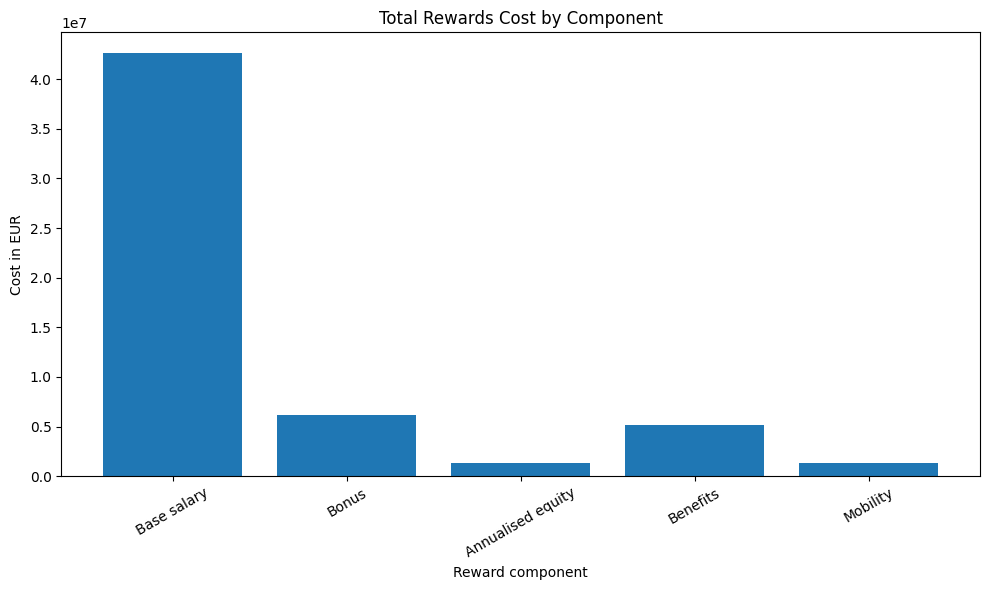

In [134]:
#Chart for better visualization

plt.figure(figsize=(10, 6))

plt.bar(
    reward_cost_structure["Reward_Component"],
    reward_cost_structure["Cost_EUR"]
)

plt.title("Total Rewards Cost by Component")
plt.xlabel("Reward component")
plt.ylabel("Cost in EUR")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

*   Base salary will normally represent the largest portion of reward spending.
*   Equity represents long-term reward.
*   Benefits support employee security and experience.
*   Mobility costs apply to a smaller employee population but can be expensive per employee.
*   The organisation should evaluate both total cost and employee value.




###8.0 Compensation Market Analysis

####8.1 Average Salary and Compa-Ratio by Country

In [135]:
compensation_by_country = (
    df.groupby("Country")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Salary_EUR=("Base_Salary_EUR", "mean"),
        Median_Salary_EUR=("Base_Salary_EUR", "median"),
        Average_Market_Midpoint_EUR=("Market_Midpoint_EUR", "mean"),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
    .sort_values("Average_Compa_Ratio")
)

compensation_by_country

,Employees,Average_Salary_EUR,Median_Salary_EUR,Average_Market_Midpoint_EUR,Average_Compa_Ratio,Attrition_Rate
Country,,,,,,
Portugal,71,61612.025493,56130.42,68749.824648,0.901070,0.323944
Australia,37,77261.185405,72789.25,78957.282703,0.977405,0.243243
United Kingdom,76,94534.923421,85525.24,95238.824474,0.985355,0.171053
Sweden,90,82582.545556,75687.50,83650.361889,0.985867,0.133333
Germany,42,82425.587619,73415.40,83286.390476,0.986357,0.095238
Singapore,50,86903.490800,81021.94,87940.111200,0.990560,0.180000
Netherlands,55,85010.254909,73160.42,85664.904909,0.991764,0.181818
United States,79,104541.345949,87801.75,104014.309241,1.002241,0.113924


In [136]:
#Formatting the percentage
compensation_by_country.style.format({
    "Average_Salary_EUR": "€{:,.0f}",
    "Median_Salary_EUR": "€{:,.0f}",
    "Average_Market_Midpoint_EUR": "€{:,.0f}",
    "Average_Compa_Ratio": "{:.2f}",
    "Attrition_Rate": "{:.1%}"
})

,Employees,Average_Salary_EUR,Median_Salary_EUR,Average_Market_Midpoint_EUR,Average_Compa_Ratio,Attrition_Rate
Country,,,,,,
Portugal,71,"€61,612","€56,130","€68,750",0.90,32.4%
Australia,37,"€77,261","€72,789","€78,957",0.98,24.3%
United Kingdom,76,"€94,535","€85,525","€95,239",0.99,17.1%
Sweden,90,"€82,583","€75,688","€83,650",0.99,13.3%
Germany,42,"€82,426","€73,415","€83,286",0.99,9.5%
Singapore,50,"€86,903","€81,022","€87,940",0.99,18.0%
Netherlands,55,"€85,010","€73,160","€85,665",0.99,18.2%
United States,79,"€104,541","€87,802","€104,014",1.00,11.4%


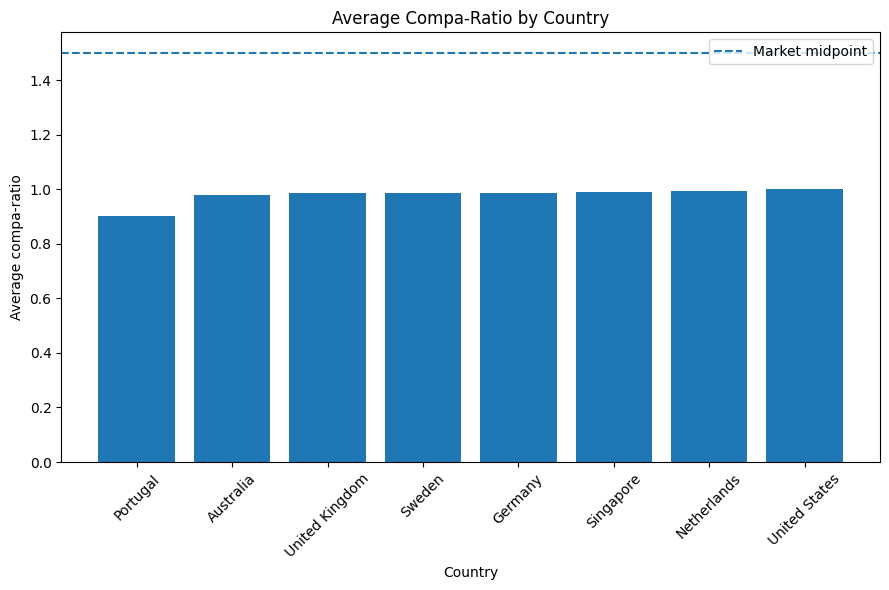

In [137]:
#Compa-ratio Chart for improved visualisation

country_compa = compensation_by_country.reset_index()

plt.figure(figsize=(9, 6))

plt.bar(
    country_compa["Country"],
    country_compa["Average_Compa_Ratio"]
)

plt.axhline(
    1.50,
    linestyle="--",
    label="Market midpoint"
)

plt.title("Average Compa-Ratio by Country")
plt.xlabel("Country")
plt.ylabel("Average compa-ratio")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

####8.2 Employees Below Market

In [138]:
below_market = df[df["Compa_Ratio"] < 0.90]

below_market_summary = (
    below_market.groupby("Country")
    .agg(
        Employees_Below_Market=("Employee_ID", "count"),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Average_Salary_EUR=("Base_Salary_EUR", "mean"),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
    .sort_values("Employees_Below_Market", ascending=False)
)

below_market_summary

,Employees_Below_Market,Average_Compa_Ratio,Average_Salary_EUR,Attrition_Rate
Country,,,,
Portugal,32,0.826531,60379.685625,0.625000
Sweden,10,0.875700,74219.265000,0.200000
Singapore,9,0.845111,72841.245556,0.555556
United Kingdom,9,0.863222,51245.207778,0.555556
United States,9,0.863667,73978.643333,0.333333
Netherlands,8,0.859875,68682.783750,0.625000
Australia,6,0.872167,69567.048333,0.500000
Germany,5,0.850000,62431.258000,0.600000


In [139]:
#Calculating the proportion below market by country

below_market_rate_by_country = (
    df.assign(Below_Market_Flag=(df["Compa_Ratio"] < 0.90).astype(int))
    .groupby("Country")
    .agg(
        Employees=("Employee_ID", "count"),
        Employees_Below_Market=("Below_Market_Flag", "sum"),
        Percentage_Below_Market=("Below_Market_Flag", "mean")
    )
    .sort_values("Percentage_Below_Market", ascending=False)
)

below_market_rate_by_country

,Employees,Employees_Below_Market,Percentage_Below_Market
Country,,,
Portugal,71,32,0.450704
Singapore,50,9,0.180000
Australia,37,6,0.162162
Netherlands,55,8,0.145455
Germany,42,5,0.119048
United Kingdom,76,9,0.118421
United States,79,9,0.113924
Sweden,90,10,0.111111


###9.0 Analyse Attrition by Market Position

In [140]:
#Attention here

attrition_by_market_position = (
    df.groupby("Market_Position_Category")
    .agg(
        Employees=("Employee_ID", "count"),
        Voluntary_Exits=("Attrition_Flag", "sum"),
        Attrition_Rate=("Attrition_Flag", "mean"),
        Average_Reward_Satisfaction=("Reward_Satisfaction", "mean"),
        Average_Engagement=("Engagement_Score", "mean")
    )
)

attrition_by_market_position

,Employees,Voluntary_Exits,Attrition_Rate,Average_Reward_Satisfaction,Average_Engagement
Market_Position_Category,,,,,
100%–110% of market,185,16,0.086486,7.821622,75.335135
90%–99% of market,200,25,0.125000,6.880000,69.370000
Above 110% of market,27,2,0.074074,8.814815,77.148148
Below 90% of market,88,46,0.522727,5.590909,65.625000


In [141]:
#Sorting the categories manually

market_order = [
    "Below 90% of market",
    "90%–99% of market",
    "100%–110% of market",
    "Above 110% of market"
]

attrition_by_market_position = (
    attrition_by_market_position
    .reindex(market_order)
)

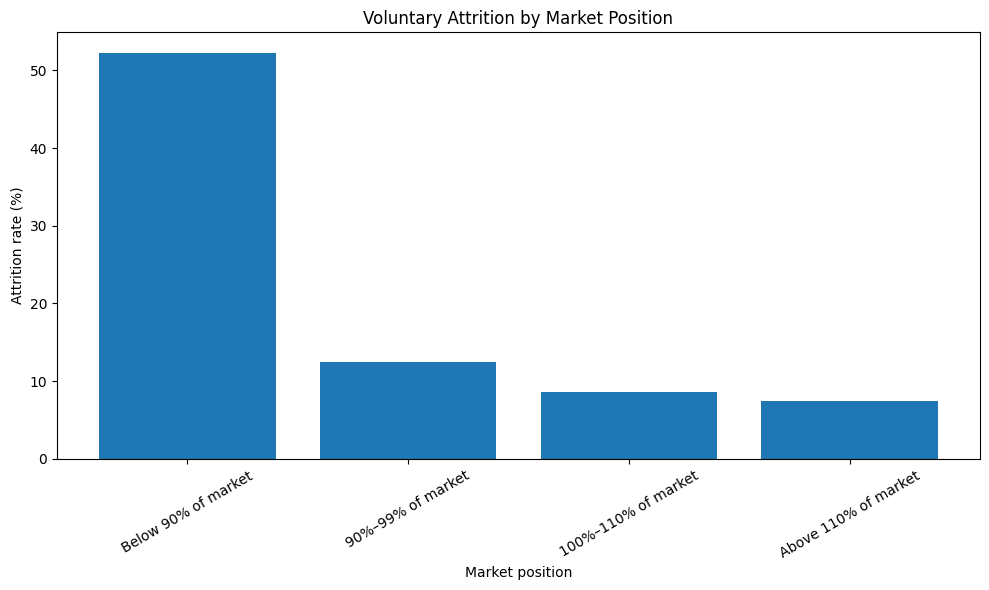

In [142]:
#Visualise it using the chart

market_attrition_chart = (
    attrition_by_market_position
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    market_attrition_chart["Market_Position_Category"],
    market_attrition_chart["Attrition_Rate"] * 100
)

plt.title("Voluntary Attrition by Market Position")
plt.xlabel("Market position")
plt.ylabel("Attrition rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [143]:
#Direct comparison

below_90_attrition = df.loc[
    df["Compa_Ratio"] < 0.90,
    "Attrition_Flag"
].mean()

at_or_above_market_attrition = df.loc[
    df["Compa_Ratio"] >= 1.00,
    "Attrition_Flag"
].mean()

print(f"Attrition below 90% of market: {below_90_attrition:.1%}")
print(
    "Attrition at or above market: "
    f"{at_or_above_market_attrition:.1%}"
)

Attrition below 90% of market: 52.3%
Attrition at or above market: 8.5%


In [144]:
#Calculating the relative difference

relative_attrition_risk = (
    below_90_attrition /
    at_or_above_market_attrition
)

print(
    "Employees below 90% of market experience "
    f"{relative_attrition_risk:.1f} times the attrition rate "
    "of employees paid at or above market."
)

Employees below 90% of market experience 6.2 times the attrition rate of employees paid at or above market.


Employees positioned below 90% of the market midpoint experienced materially higher voluntary attrition than employees positioned at or above market.

The result indicates a strong relationship between compensation competitiveness and retention. However, the analysis shows association rather than proof that low pay directly caused each employee to leave.

###10.0 Compensation Analysis by Job Level and Department

####10.1 By Job Level

In [145]:
compensation_by_level = (
    df.groupby("Job_Level")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Salary_EUR=("Base_Salary_EUR", "mean"),
        Median_Salary_EUR=("Base_Salary_EUR", "median"),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Average_Bonus_EUR=("Bonus_Paid_EUR", "mean"),
        Average_Total_Rewards_EUR=("Total_Rewards_Cost_EUR", "mean"),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
)

compensation_by_level

,Employees,Average_Salary_EUR,Median_Salary_EUR,Average_Compa_Ratio,Average_Bonus_EUR,Average_Total_Rewards_EUR,Attrition_Rate
Job_Level,,,,,,,
L1,60,42109.265833,40247.155,0.975933,1962.422500,54923.873333,0.200000
L2,113,57857.832212,57914.660,0.979372,4593.230442,74269.956195,0.150442
L3,133,73701.549624,75746.080,0.969361,7269.974511,93707.156541,0.187970
L4,84,99179.692619,105078.845,0.984226,14716.668452,131358.426190,0.178571
L5,79,130824.435443,127923.270,0.985532,25760.248608,178849.380886,0.164557
L6,31,163179.317742,159905.230,0.959742,40474.241613,232424.711290,0.225806


In [146]:
#Formatting the percentage
compensation_by_level.style.format({
    "Average_Salary_EUR": "€{:,.0f}",
    "Median_Salary_EUR": "€{:,.0f}",
    "Average_Compa_Ratio": "{:.2f}",
    "Average_Bonus_EUR": "€{:,.0f}",
    "Average_Total_Rewards_EUR": "€{:,.0f}",
    "Attrition_Rate": "{:.1%}"
})

,Employees,Average_Salary_EUR,Median_Salary_EUR,Average_Compa_Ratio,Average_Bonus_EUR,Average_Total_Rewards_EUR,Attrition_Rate
Job_Level,,,,,,,
L1,60,"€42,109","€40,247",0.98,"€1,962","€54,924",20.0%
L2,113,"€57,858","€57,915",0.98,"€4,593","€74,270",15.0%
L3,133,"€73,702","€75,746",0.97,"€7,270","€93,707",18.8%
L4,84,"€99,180","€105,079",0.98,"€14,717","€131,358",17.9%
L5,79,"€130,824","€127,923",0.99,"€25,760","€178,849",16.5%
L6,31,"€163,179","€159,905",0.96,"€40,474","€232,425",22.6%


####10.2 By Department

In [147]:
compensation_by_department = (
    df.groupby("Department")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Salary_EUR=("Base_Salary_EUR", "mean"),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Average_Bonus_EUR=("Bonus_Paid_EUR", "mean"),
        Equity_Participation=("Has_Equity", lambda x: (x == "Yes").mean()),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
    .sort_values("Average_Compa_Ratio")
)

compensation_by_department

,Employees,Average_Salary_EUR,Average_Compa_Ratio,Average_Bonus_EUR,Equity_Participation,Attrition_Rate
Department,,,,,,
Sales,73,83117.734795,0.961685,13212.503425,1.0,0.246575
People,41,70905.022927,0.968171,10031.899512,1.0,0.146341
Operations,26,70099.381154,0.968962,10497.504615,1.0,0.346154
Marketing,28,69843.169643,0.971929,9440.912143,1.0,0.214286
Product,42,84969.540000,0.973881,11495.197619,1.0,0.190476
Engineering,163,97402.587546,0.980706,14050.360798,1.0,0.141104
Finance,39,81039.715897,0.983026,11134.188718,1.0,0.153846
Legal,31,86328.664516,0.987097,11681.738065,1.0,0.129032
Customer Success,57,79940.479123,0.990053,11353.905965,1.0,0.157895


In [148]:
#Formatting the percentage
compensation_by_department.style.format({
    "Average_Salary_EUR": "€{:,.0f}",
    "Average_Compa_Ratio": "{:.2f}",
    "Average_Bonus_EUR": "€{:,.0f}",
    "Equity_Participation_EUR": "€{:,.0f}",
    "Attrition_Rate": "{:.1%}"
})

,Employees,Average_Salary_EUR,Average_Compa_Ratio,Average_Bonus_EUR,Equity_Participation,Attrition_Rate
Department,,,,,,
Sales,73,"€83,118",0.96,"€13,213",1.000000,24.7%
People,41,"€70,905",0.97,"€10,032",1.000000,14.6%
Operations,26,"€70,099",0.97,"€10,498",1.000000,34.6%
Marketing,28,"€69,843",0.97,"€9,441",1.000000,21.4%
Product,42,"€84,970",0.97,"€11,495",1.000000,19.0%
Engineering,163,"€97,403",0.98,"€14,050",1.000000,14.1%
Finance,39,"€81,040",0.98,"€11,134",1.000000,15.4%
Legal,31,"€86,329",0.99,"€11,682",1.000000,12.9%
Customer Success,57,"€79,940",0.99,"€11,354",1.000000,15.8%


###11.0 Identify High-performing Employees at Reward Risk

In [149]:
#Relevant for fast-growing companies

high_performer_risk = df[
    (df["Performance_Rating"] >= 4) &
    (df["Compa_Ratio"] < 0.95)
].copy()

In [150]:
#Count them

high_performer_risk["Employee_ID"].nunique()

56

In [151]:
#Summary by country

high_performer_risk_by_country = (
    high_performer_risk.groupby("Country")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Average_Attrition_Risk=(
            "Predicted_Attrition_Risk_Pct",
            "mean"
        ),
        Actual_Attrition_Rate=("Attrition_Flag", "mean"),
        Critical_Roles=("Critical_Role", lambda x: (x == "Yes").sum())
    )
    .sort_values("Employees", ascending=False)
)

high_performer_risk_by_country

,Employees,Average_Compa_Ratio,Average_Attrition_Risk,Actual_Attrition_Rate,Critical_Roles
Country,,,,,
Portugal,23,0.877261,43.426087,0.347826,6
United Kingdom,10,0.907700,24.960000,0.200000,2
Sweden,7,0.909571,29.228571,0.000000,1
Australia,6,0.902833,34.300000,0.333333,0
Singapore,3,0.888333,57.500000,0.333333,0
Netherlands,3,0.897667,35.400000,0.333333,0
Germany,2,0.893500,71.150000,1.000000,0
United States,2,0.909500,25.150000,0.000000,0


In [152]:
#Summary by department

high_performer_risk_by_department = (
    high_performer_risk.groupby("Department")
    .agg(
        Employees=("Employee_ID", "count"),
        Critical_Roles=("Critical_Role", lambda x: (x == "Yes").sum()),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
    .sort_values("Employees", ascending=False)
)

high_performer_risk_by_department

,Employees,Critical_Roles,Average_Compa_Ratio,Attrition_Rate
Department,,,,
Engineering,17,6,0.901471,0.352941
Sales,8,2,0.881375,0.125000
People,7,0,0.871571,0.285714
Marketing,6,0,0.904500,0.333333
Finance,6,0,0.913333,0.166667
Operations,4,0,0.884000,0.500000
Legal,4,0,0.881500,0.250000
Product,3,1,0.917333,0.000000
Customer Success,1,0,0.804000,1.000000


The highest-priority retention population consists of employees who combine:

- Strong performance.
- Compensation below the desired market position.
- Critical-role status.
- High predicted retention risk.

A targeted intervention may be financially more efficient than applying a uniform salary increase across the workforce.

###12.0 Performance and Bonus Differentiation Analysis

####12.1 Bonus by Performance Rating

In [153]:
bonus_by_performance = (
    df.groupby("Performance_Rating")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Base_Salary_EUR=("Base_Salary_EUR", "mean"),
        Average_Bonus_EUR=("Bonus_Paid_EUR", "mean"),
        Average_Target_Bonus_Pct=("Target_Bonus_Pct", "mean"),
        Average_Merit_Increase_Pct=("Merit_Increase_Pct", "mean")
    )
)

bonus_by_performance

,Employees,Average_Base_Salary_EUR,Average_Bonus_EUR,Average_Target_Bonus_Pct,Average_Merit_Increase_Pct
Performance_Rating,,,,,
1,15,61928.034667,4095.436667,9.066667,0.033333
2,54,82958.099259,9681.538148,12.537037,0.570370
3,234,83708.271197,11140.008077,12.008547,1.798718
4,153,89732.682353,14663.328954,12.843137,3.135948
5,44,87865.608636,15799.146591,12.750000,4.493182


In [154]:
#Formatting the percentage
bonus_by_performance.style.format({
    "Average_Base_Salary_EUR": "€{:,.0f}",
    "Average_Bonus_EUR": "€{:,.0f}",
    "Average_Target_Bonus_Pct": "{:.2f}",
    "Average_Merit_Increase_Pct": "{:.2f}"
})

,Employees,Average_Base_Salary_EUR,Average_Bonus_EUR,Average_Target_Bonus_Pct,Average_Merit_Increase_Pct
Performance_Rating,,,,,
1,15,"€61,928","€4,095",9.07,0.03
2,54,"€82,958","€9,682",12.54,0.57
3,234,"€83,708","€11,140",12.01,1.80
4,153,"€89,733","€14,663",12.84,3.14
5,44,"€87,866","€15,799",12.75,4.49


In [155]:
#Calculating bonus as a percentage of salary:

df["Actual_Bonus_Pct"] = (
    df["Bonus_Paid_EUR"] /
    df["Base_Salary_EUR"] *
    100
)

bonus_differentiation = (
    df.groupby("Performance_Rating")
    .agg(
        Average_Actual_Bonus_Pct=("Actual_Bonus_Pct", "mean"),
        Average_Merit_Increase_Pct=("Merit_Increase_Pct", "mean")
    )
)

bonus_differentiation

,Average_Actual_Bonus_Pct,Average_Merit_Increase_Pct
Performance_Rating,,
1,5.769024,0.033333
2,10.178928,0.570370
3,11.290199,1.798718
4,13.715967,3.135948
5,15.281335,4.493182


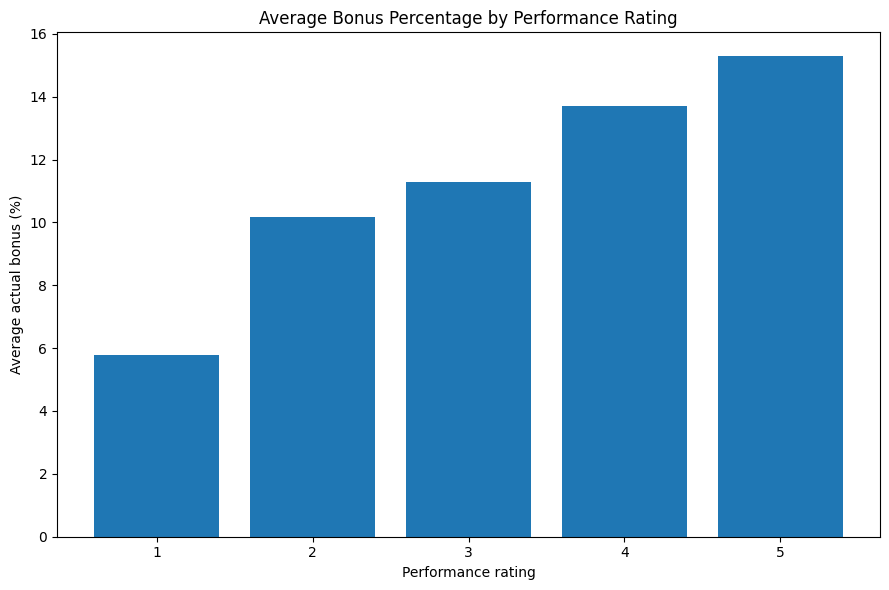

In [156]:
#Chart for visualisation

plt.figure(figsize=(9, 6))

plt.bar(
    bonus_differentiation.index.astype(str),
    bonus_differentiation["Average_Actual_Bonus_Pct"]
)

plt.title("Average Bonus Percentage by Performance Rating")
plt.xlabel("Performance rating")
plt.ylabel("Average actual bonus (%)")
plt.tight_layout()
plt.show()

*   Are higher performers meaningfully differentiated?
*   Is the bonus difference large enough?
*   Do high performers below market receive stronger merit increases?




###13.0 Equity Program Analysis

####13.1 Equity Participation

In [157]:
equity_participation = (
    df.groupby("Has_Equity")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Grant_Value_EUR=("Grant_Value_EUR", "mean"),
        Average_Unvested_Value_EUR=("Unvested_Value_EUR", "mean"),
        Attrition_Rate=("Attrition_Flag", "mean"),
        Average_Reward_Satisfaction=("Reward_Satisfaction", "mean"),
        Average_Engagement=("Engagement_Score", "mean")
    )
)

equity_participation

,Employees,Average_Grant_Value_EUR,Average_Unvested_Value_EUR,Attrition_Rate,Average_Reward_Satisfaction,Average_Engagement
Has_Equity,,,,,,
Yes,500,10824.81704,7010.47732,0.178,7.106,71.338


####13.2 Equity Participation by Level

In [158]:
equity_by_level = (
    df.groupby("Job_Level")
    .agg(
        Employees=("Employee_ID", "count"),
        Employees_With_Equity=(
            "Has_Equity",
            lambda x: (x == "Yes").sum()
        ),
        Equity_Participation_Rate=(
            "Has_Equity",
            lambda x: (x == "Yes").mean()
        ),
        Average_Grant_Value_EUR=("Grant_Value_EUR", "mean"),
        Total_Unvested_Value_EUR=("Unvested_Value_EUR", "sum")
    )
)

equity_by_level

,Employees,Employees_With_Equity,Equity_Participation_Rate,Average_Grant_Value_EUR,Total_Unvested_Value_EUR
Job_Level,,,,,
L1,60,60,1.0,0.000000,0.00
L2,113,113,1.0,842.534071,54866.06
L3,133,133,1.0,5533.709023,433608.17
L4,84,84,1.0,11339.519524,607836.56
L5,79,79,1.0,25713.421013,1232253.15
L6,31,31,1.0,51527.063548,1176674.72


####13.3 Equity by Department

In [159]:
equity_by_department = (
    df.groupby("Department")
    .agg(
        Employees=("Employee_ID", "count"),
        Equity_Participation_Rate=(
            "Has_Equity",
            lambda x: (x == "Yes").mean()
        ),
        Average_Grant_Value_EUR=("Grant_Value_EUR", "mean"),
        Total_Unvested_Value_EUR=("Unvested_Value_EUR", "sum")
    )
    .sort_values("Equity_Participation_Rate", ascending=False)
)

equity_by_department

,Employees,Equity_Participation_Rate,Average_Grant_Value_EUR,Total_Unvested_Value_EUR
Department,,,,
Customer Success,57,1.0,13429.169474,431537.86
Engineering,163,1.0,12622.103190,1434686.32
Finance,39,1.0,7819.254615,131220.13
Legal,31,1.0,6107.298387,71766.48
Marketing,28,1.0,10632.708214,213609.66
Operations,26,1.0,8597.091538,173733.22
People,41,1.0,9626.548049,291816.37
Product,42,1.0,7812.843095,180737.30
Sales,73,1.0,11660.243425,576131.32


####13.4 Compare Attrition Among Equity-eligible Employees

In [160]:
#Comparing similar employees

eligible_levels = ["L3", "L4", "L5", "L6"]

equity_eligible_df = df[
    df["Job_Level"].isin(eligible_levels)
].copy()

equity_attrition_comparison = (
    equity_eligible_df.groupby("Has_Equity")
    .agg(
        Employees=("Employee_ID", "count"),
        Attrition_Rate=("Attrition_Flag", "mean"),
        Average_Compa_Ratio=("Compa_Ratio", "mean"),
        Average_Engagement=("Engagement_Score", "mean"),
        Average_Reward_Satisfaction=("Reward_Satisfaction", "mean")
    )
)

equity_attrition_comparison

,Employees,Attrition_Rate,Average_Compa_Ratio,Average_Engagement,Average_Reward_Satisfaction
Has_Equity,,,,,
Yes,327,0.183486,0.976174,71.559633,7.229358


Among employees at comparable eligible levels, employees with equity grants experienced lower voluntary attrition and stronger reward satisfaction than employees without equity.

Equity may contribute to long-term retention by providing employees with an ownership incentive and future vesting value. However, equity should not be considered a substitute for competitive base salary.

###14.0 Vesting Milestones Analysis

In [161]:
#Analysis date

analysis_date = pd.Timestamp("2026-07-01")

In [162]:
#Calculating days until vesting

df["Days_To_Next_Vesting"] = (
    df["Next_Vesting_Date"] - analysis_date
).dt.days

In [163]:
#Identify vesting within 180 days

vesting_next_180_days = df[
    df["Days_To_Next_Vesting"].between(0, 180)
].copy()

In [164]:
#Summary

vesting_summary = (
    vesting_next_180_days.groupby("Job_Level")
    .agg(
        Employees_With_Vesting=("Employee_ID", "count"),
        Unvested_Value_EUR=("Unvested_Value_EUR", "sum"),
        Average_Retention_Risk=(
            "Predicted_Attrition_Risk_Pct",
            "mean"
        )
    )
)

vesting_summary

,Employees_With_Vesting,Unvested_Value_EUR,Average_Retention_Risk
Job_Level,,,
L2,12,27596.25,10.191667
L3,31,187938.48,13.048387
L4,15,236280.41,15.713333
L5,18,476076.07,8.416667
L6,8,464140.05,20.250000


In [165]:
high_risk_vesting = vesting_next_180_days[
    vesting_next_180_days["Retention_Risk"] == "High"
].groupby(['Country', 'Department', 'Job_Level']).agg(
    Employees_At_Risk=('Employee_ID', 'count'),
    Total_Unvested_Value_EUR=('Unvested_Value_EUR', 'sum'),
    Average_Predicted_Attrition_Risk_Pct=('Predicted_Attrition_Risk_Pct', 'mean')
).sort_values('Employees_At_Risk', ascending=False)

high_risk_vesting

Employees_At_Risk  \
Country       Department  Job_Level                      
United States Engineering L4                         2   
Netherlands   People      L3                         1   
Australia     People      L4                         1   
Netherlands   Product     L2                         1   
Portugal      Engineering L3                         1   
                          L6                         1   
                          L5                         1   
              Product     L3                         1   
Singapore     Product     L3                         1   
Sweden        Engineering L3                         1   
              Sales       L6                         1   

                                     Total_Unvested_Value_EUR  \
Country       Department  Job_Level                             
United States Engineering L4                         48945.99   
Netherlands   People      L3                          2993.96   
Australia     People      L4                          4901.96   
Netherlands   Product     L2                          1675.88   
Portugal      Engineering L3                          2173.07   
                          L6                         73805.34   
                          L5                         52329.12   
              Product     L3                          6810.82   
Singapore     Product     L3                          7773.44   
Sweden        Engineering L3                          2439.94   
              Sales       L6                         61474.97   

                                     Average_Predicted_Attrition_Risk_Pct  
Country       Department  Job_Level                                        
United States Engineering L4                                         54.8  
Netherlands   People      L3                                         62.2  
Australia     People      L4                                         31.0  
Netherlands   Product     L2                                         38.9  
Portugal      Engineering L3                                         58.7  
                          L6                                         45.0  
                          L5                                         42.6  
              Product     L3                                         33.2  
Singapore     Product     L3                                         46.3  
Sweden        Engineering L3                                         37.8  
              Sales       L6                                         52.5

For each group, you can see:

*   Employees_At_Risk: The number of employees in that category.
*   Total_Unvested_Value_EUR: The sum of unvested equity value for those employees.
*   Average_Predicted_Attrition_Risk_Pct: The average predicted attrition risk percentage for that group.
*   This aggregated output helps identify which countries, departments, and job levels have the most high-risk employees nearing vesting, without revealing individual employee data.

###15.0 Benefits Costs and Utilisation Analysis

####15.1 Overall Benefits Summary

In [166]:
benefits_summary = pd.DataFrame({
    "Benefit": [
        "Pension",
        "Health insurance",
        "Learning budget",
        "Wellbeing budget",
        "Home-office allowance"
    ],
    "Total_Cost_EUR": [
        df["Pension_Cost_EUR"].sum(),
        df["Health_Insurance_Cost_EUR"].sum(),
        df["Learning_Budget_EUR"].sum(),
        df["Wellbeing_Budget_EUR"].sum(),
        df["Home_Office_Allowance_EUR"].sum()
    ]
})

benefits_summary

,Benefit,Total_Cost_EUR
0,Pension,2680303.82
1,Health insurance,1106530.35
2,Learning budget,821500.00
3,Wellbeing budget,270600.00
4,Home-office allowance,250000.00


In [167]:
#Formatting the amount
benefits_summary.style.format({
    "Total_Cost_EUR": "€{:,.0f}"
})

,Benefit,Total_Cost_EUR
0,Pension,"€2,680,304"
1,Health insurance,"€1,106,530"
2,Learning budget,"€821,500"
3,Wellbeing budget,"€270,600"
4,Home-office allowance,"€250,000"


####15.2 Learning and Wellbeing Utilisation

In [168]:
utilisation_summary = pd.DataFrame({
    "Benefit": [
        "Learning budget",
        "Wellbeing budget"
    ],
    "Average_Utilisation_Pct": [
        df["Learning_Utilisation_Pct"].mean(),
        df["Wellbeing_Utilisation_Pct"].mean()
    ],
    "Total_Budget_EUR": [
        df["Learning_Budget_EUR"].sum(),
        df["Wellbeing_Budget_EUR"].sum()
    ],
    "Total_Value_Used_EUR": [
        df["Learning_Value_Used_EUR"].sum(),
        df["Wellbeing_Value_Used_EUR"].sum()
    ],
    "Total_Unused_Value_EUR": [
        df["Unused_Learning_Value_EUR"].sum(),
        df["Unused_Wellbeing_Value_EUR"].sum()
    ]
})

utilisation_summary

,Benefit,Average_Utilisation_Pct,Total_Budget_EUR,Total_Value_Used_EUR,Total_Unused_Value_EUR
0,Learning budget,47.4584,821500,389021.5,432478.5
1,Wellbeing budget,25.4172,270600,68889.8,201710.2


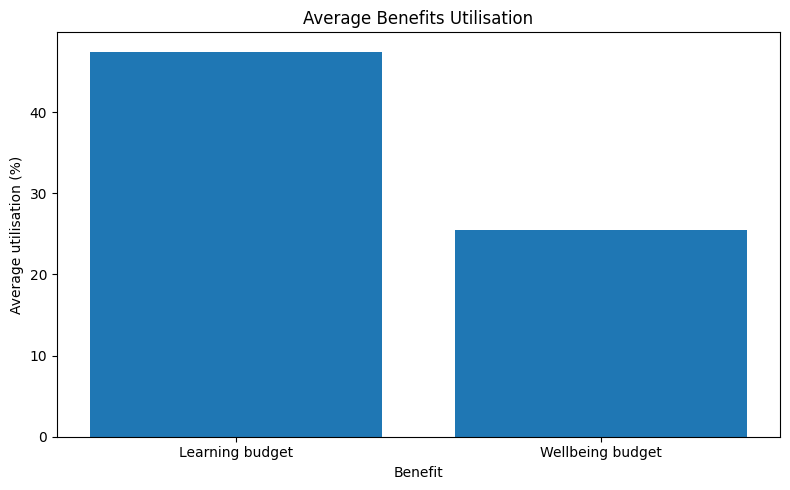

In [169]:
#Chart

plt.figure(figsize=(8, 5))

plt.bar(
    utilisation_summary["Benefit"],
    utilisation_summary["Average_Utilisation_Pct"]
)

plt.title("Average Benefits Utilisation")
plt.xlabel("Benefit")
plt.ylabel("Average utilisation (%)")
plt.tight_layout()
plt.show()

####15.3 Benefits by Country

In [170]:
benefits_by_country = (
    df.groupby("Country")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Benefits_Cost_EUR=("Benefits_Cost_EUR", "mean"),
        Average_Benefits_Utilisation=(
            "Benefits_Utilisation_Pct",
            "mean"
        ),
        Average_Learning_Utilisation=(
            "Learning_Utilisation_Pct",
            "mean"
        ),
        Average_Wellbeing_Utilisation=(
            "Wellbeing_Utilisation_Pct",
            "mean"
        ),
        Average_Reward_Satisfaction=(
            "Reward_Satisfaction",
            "mean"
        )
    )
)

benefits_by_country

,Employees,Average_Benefits_Cost_EUR,Average_Benefits_Utilisation,Average_Learning_Utilisation,Average_Wellbeing_Utilisation,Average_Reward_Satisfaction
Country,,,,,,
Australia,37,13407.521081,90.562162,48.375676,27.943243,7.081081
Germany,42,9844.940238,86.350000,44.664286,27.385714,7.071429
Netherlands,55,11038.443818,87.465455,48.756364,21.838182,7.418182
Portugal,71,6778.262535,81.657746,48.780282,24.484507,6.042254
Singapore,50,8890.385600,85.026000,46.818000,26.538000,7.360000
Sweden,90,11619.669333,88.733333,47.847778,26.383333,7.288889
United Kingdom,76,10695.256316,87.259211,46.585526,24.368421,7.315789
United States,79,10479.344684,87.410127,47.224051,25.716456,7.303797


Wellbeing allowances show materially lower utilisation than learning budgets. This may indicate limited awareness, poor benefit design, administrative difficulty, or weak alignment with employee preferences.

The organisation should not immediately remove the benefit. It should first investigate employee awareness, vendor experience, eligibility rules, and regional relevance.

###16.0 Mobility Costs Analysis

In [171]:
#Filter mobility cases

mobility_df = df[
    df["Mobility_Status"] != "None"
].copy()

In [172]:
#Count mobility cases

mobility_df["Employee_ID"].nunique()

500

####16.1 Cost by Component

In [173]:
mobility_cost_summary = pd.DataFrame({
    "Mobility_Component": [
        "Relocation",
        "Visa",
        "Housing",
        "Tax equalisation"
    ],
    "Cost_EUR": [
        mobility_df["Relocation_Cost_EUR"].sum(),
        mobility_df["Visa_Cost_EUR"].sum(),
        mobility_df["Housing_Allowance_EUR"].sum(),
        mobility_df["Tax_Equalisation_EUR"].sum()
    ]
})

mobility_cost_summary["Percentage_of_Mobility_Cost"] = (
    mobility_cost_summary["Cost_EUR"] /
    mobility_cost_summary["Cost_EUR"].sum()
)

mobility_cost_summary

,Mobility_Component,Cost_EUR,Percentage_of_Mobility_Cost
0,Relocation,339819.68,0.258202
1,Visa,108717.01,0.082605
2,Housing,620047.11,0.471125
3,Tax equalisation,247515.43,0.188067


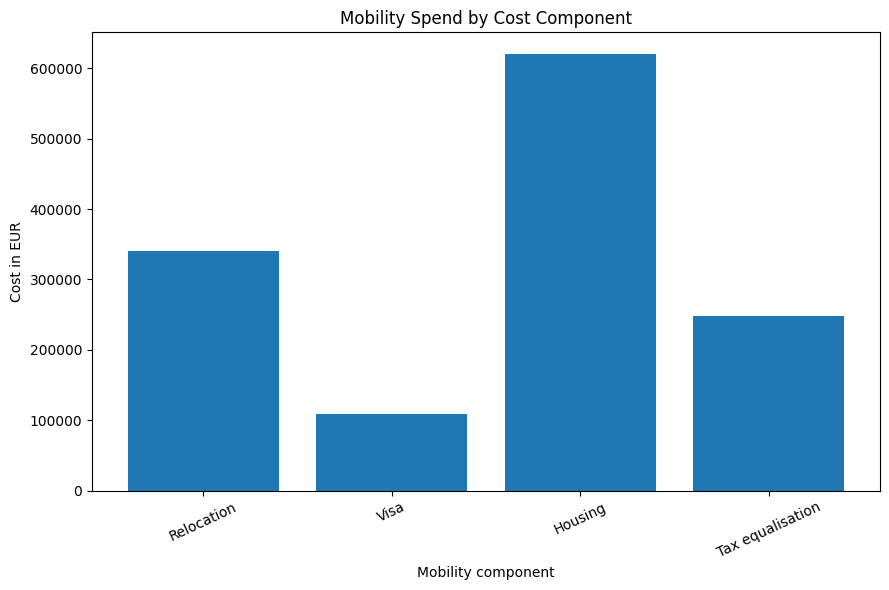

In [174]:
#Chart

plt.figure(figsize=(9, 6))

plt.bar(
    mobility_cost_summary["Mobility_Component"],
    mobility_cost_summary["Cost_EUR"]
)

plt.title("Mobility Spend by Cost Component")
plt.xlabel("Mobility component")
plt.ylabel("Cost in EUR")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

####16.2 Mobility Cost by Assignment Type

In [175]:
mobility_by_assignment = (
    mobility_df.groupby("Assignment_Type")
    .agg(
        Assignments=("Employee_ID", "count"),
        Average_Cost_EUR=("Total_Mobility_Cost_EUR", "mean"),
        Total_Cost_EUR=("Total_Mobility_Cost_EUR", "sum")
    )
    .sort_values("Total_Cost_EUR", ascending=False)
)

mobility_by_assignment

,Assignments,Average_Cost_EUR,Total_Cost_EUR
Assignment_Type,,,
Long-term assignment,10,63910.632000,639106.32
Short-term assignment,9,45477.077778,409293.70
Relocation,10,26769.921000,267699.21


####16.3 Mobility Cost by Host Country

In [176]:
mobility_by_host_country = (
    mobility_df.groupby("Host_Country")
    .agg(
        Assignments=("Employee_ID", "count"),
        Average_Cost_EUR=("Total_Mobility_Cost_EUR", "mean"),
        Total_Cost_EUR=("Total_Mobility_Cost_EUR", "sum")
    )
    .sort_values("Total_Cost_EUR", ascending=False)
)

mobility_by_host_country

,Assignments,Average_Cost_EUR,Total_Cost_EUR
Host_Country,,,
Sweden,7,49135.292857,343947.05
Netherlands,4,49277.677500,197110.71
Germany,4,47392.937500,189571.75
Singapore,4,37824.520000,151298.08
Portugal,2,68730.900000,137461.80
United States,3,39775.103333,119325.31
Australia,2,46464.990000,92929.98
United Kingdom,3,28151.516667,84454.55


####16.4 Assignments Ending Soon

In [177]:
df["Days_To_Assignment_End"] = (
    df["Assignment_End_Date"] - analysis_date
).dt.days

assignments_ending_soon = df[
    df["Days_To_Assignment_End"].between(0, 90)
].groupby(["Origin_Country", "Host_Country", "Assignment_Type"]).agg(
    Number_of_Assignments=("Employee_ID", "count"),
    Total_Mobility_Cost_EUR=("Total_Mobility_Cost_EUR", "sum")
).sort_values("Number_of_Assignments", ascending=False)

assignments_ending_soon

Number_of_Assignments  \
Origin_Country Host_Country Assignment_Type                               
Sweden         Germany      Long-term assignment                      1   
                            Relocation                                1   

                                                  Total_Mobility_Cost_EUR  
Origin_Country Host_Country Assignment_Type                                
Sweden         Germany      Long-term assignment                 65304.10  
                            Relocation                           27143.78

The assignments_ending_soon shows aggregated data values with the number of assignments and total mobility cost for each combination of origin country, host country, and assignment type, instead of individual employee IDs.

###17.0 Reward Satisfaction and Engagement Analysis

####17.1 Correlation Analysis

In [178]:
#Select numerical values

correlation_columns = [
    "Compa_Ratio",
    "Reward_Satisfaction",
    "Manager_Satisfaction",
    "Career_Satisfaction",
    "Engagement_Score",
    "Benefits_Utilisation_Pct",
    "Annualised_Equity_EUR",
    "Predicted_Attrition_Risk_Pct",
    "Attrition_Flag"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Compa_Ratio,Reward_Satisfaction,Manager_Satisfaction,Career_Satisfaction,Engagement_Score,Benefits_Utilisation_Pct,Annualised_Equity_EUR,Predicted_Attrition_Risk_Pct,Attrition_Flag
Compa_Ratio,1.000000,0.648894,0.002679,0.040235,0.333126,0.149835,0.012305,-0.726719,-0.355556
Reward_Satisfaction,0.648894,1.000000,0.039275,0.048189,0.498590,0.179220,0.208758,-0.691364,-0.347779
Manager_Satisfaction,0.002679,0.039275,1.000000,0.038464,0.439970,-0.047371,0.016071,-0.191938,-0.127752
Career_Satisfaction,0.040235,0.048189,0.038464,1.000000,0.540831,-0.027194,-0.035343,-0.114893,-0.094108
Engagement_Score,0.333126,0.498590,0.439970,0.540831,1.000000,0.039327,0.043327,-0.508661,-0.271043
Benefits_Utilisation_Pct,0.149835,0.179220,-0.047371,-0.027194,0.039327,1.000000,0.201032,-0.138320,-0.034451
Annualised_Equity_EUR,0.012305,0.208758,0.016071,-0.035343,0.043327,0.201032,1.000000,-0.184165,-0.129927
Predicted_Attrition_Risk_Pct,-0.726719,-0.691364,-0.191938,-0.114893,-0.508661,-0.138320,-0.184165,1.000000,0.536596
Attrition_Flag,-0.355556,-0.347779,-0.127752,-0.094108,-0.271043,-0.034451,-0.129927,0.536596,1.000000


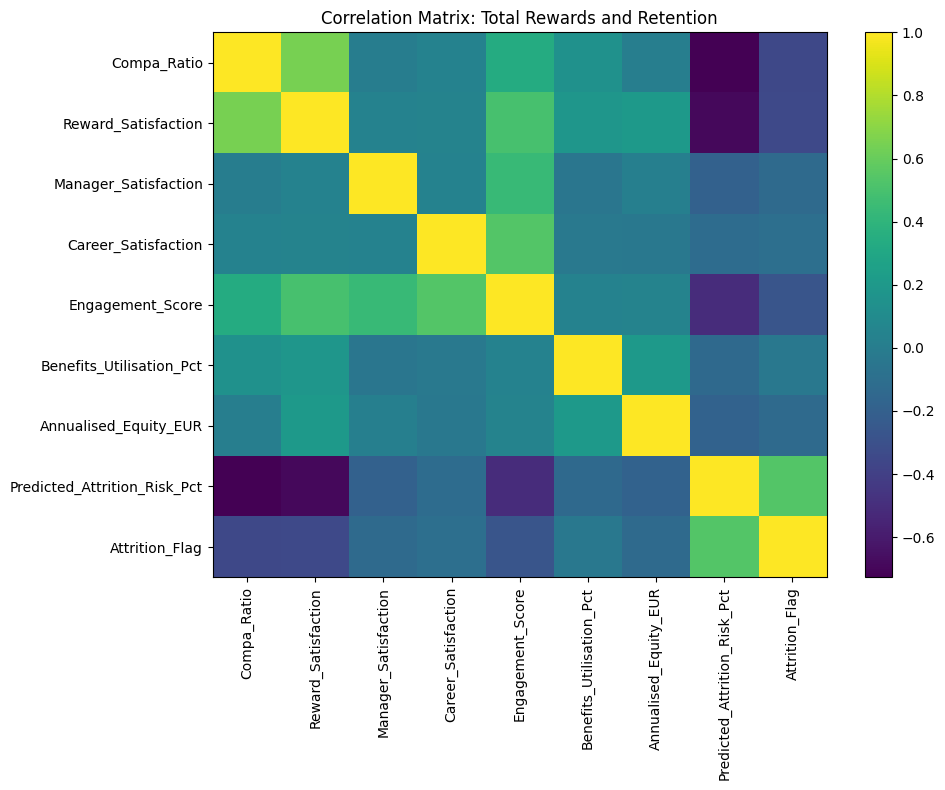

In [179]:
#Creating a simple correlation display

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix: Total Rewards and Retention")
plt.tight_layout()
plt.show()

Correlation indicates whether two variables move together, but it does not prove that one variable caused the other.

Employee retention is influenced by multiple factors, including compensation, management, career opportunities, engagement, location, and external labour-market conditions.

####17.2 Reward Satisfaction by Compa-ratio Category

In [180]:
reward_satisfaction_by_market = (
    df.groupby("Market_Position_Category")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Reward_Satisfaction=(
            "Reward_Satisfaction",
            "mean"
        ),
        Average_Engagement=("Engagement_Score", "mean"),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
    .reindex(market_order)
)

reward_satisfaction_by_market

,Employees,Average_Reward_Satisfaction,Average_Engagement,Attrition_Rate
Market_Position_Category,,,,
Below 90% of market,88,5.590909,65.625000,0.522727
90%–99% of market,200,6.880000,69.370000,0.125000
100%–110% of market,185,7.821622,75.335135,0.086486
Above 110% of market,27,8.814815,77.148148,0.074074


###18.0 Pay Equity Analysis

####18.1 Average Salary by Gender

In [181]:
salary_by_gender = (
    df.groupby("Gender")
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Salary_EUR=("Base_Salary_EUR", "mean"),
        Median_Salary_EUR=("Base_Salary_EUR", "median"),
        Average_Compa_Ratio=("Compa_Ratio", "mean")
    )
)

salary_by_gender

,Employees,Average_Salary_EUR,Median_Salary_EUR,Average_Compa_Ratio
Gender,,,,
Female,219,86354.730091,77828.090,0.972055
Male,264,83756.737841,74899.865,0.981489
Non-binary,17,92242.108235,89800.210,0.967118


####18.2 Unadjusted Pay Gap

In [182]:
#A binary Female versus Male comparison:

female_average_salary = df.loc[
    df["Gender"] == "Female",
    "Base_Salary_EUR"
].mean()

male_average_salary = df.loc[
    df["Gender"] == "Male",
    "Base_Salary_EUR"
].mean()

unadjusted_gender_pay_gap = (
    male_average_salary - female_average_salary
) / male_average_salary

print(
    f"Unadjusted female-to-male average pay gap: "
    f"{unadjusted_gender_pay_gap:.1%}"
)

Unadjusted female-to-male average pay gap: -3.1%


####18.3 Compare Within Job Level

In [183]:
salary_by_gender_and_level = (
    df.groupby(["Job_Level", "Gender"])
    .agg(
        Employees=("Employee_ID", "count"),
        Average_Salary_EUR=("Base_Salary_EUR", "mean"),
        Average_Compa_Ratio=("Compa_Ratio", "mean")
    )
    .reset_index()
)

salary_by_gender_and_level

,Job_Level,Gender,Employees,Average_Salary_EUR,Average_Compa_Ratio
0,L1,Female,26,43191.736154,0.983500
1,L1,Male,33,41706.433939,0.972030
2,L1,Non-binary,1,27258.490000,0.908000
3,L2,Female,47,58047.687872,0.988553
4,L2,Male,63,58118.612857,0.978079
5,L2,Non-binary,3,49407.033333,0.862667
6,L3,Female,56,73685.475893,0.964446
7,L3,Male,73,73437.084932,0.972014
8,L3,Non-binary,4,78753.062500,0.989750
9,L4,Female,33,96281.126970,0.964182


In [184]:
#Pivotting the table

gender_level_pivot = salary_by_gender_and_level.pivot(
    index="Job_Level",
    columns="Gender",
    values="Average_Salary_EUR"
)

gender_level_pivot

Gender,Female,Male,Non-binary
Job_Level,,,
L1,43191.736154,41706.433939,27258.490000
L2,58047.687872,58118.612857,49407.033333
L3,73685.475893,73437.084932,78753.062500
L4,96281.126970,101906.506809,91052.792500
L5,130455.103250,129515.101176,142682.566000
L6,149328.908824,179997.671429,NaN


The unadjusted pay gap compares total average pay across groups. It may reflect differences in job level, department, country, tenure, or representation.

A more meaningful pay-equity assessment compares employees in similar roles and levels or uses a multivariate regression model.

###19.0 Scenario 1 - Bring employees below 90% to 90%

In [185]:
#Creating target salary

scenario_1 = df.copy()

scenario_1["Scenario_1_Target_Salary_EUR"] = np.where(
    scenario_1["Compa_Ratio"] < 0.90,
    scenario_1["Market_Midpoint_EUR"] * 0.90,
    scenario_1["Base_Salary_EUR"]
)

In [186]:
#Calculating the increase

scenario_1["Scenario_1_Increase_EUR"] = (
    scenario_1["Scenario_1_Target_Salary_EUR"] -
    scenario_1["Base_Salary_EUR"]
)

In [187]:
#Calculating the increase in percentage

scenario_1["Scenario_1_Increase_Pct"] = (
    scenario_1["Scenario_1_Increase_EUR"] /
    scenario_1["Base_Salary_EUR"] *
    100
)

In [188]:
#Summary

scenario_1_affected = (
    scenario_1["Scenario_1_Increase_EUR"] > 0
).sum()

scenario_1_total_cost = (
    scenario_1["Scenario_1_Increase_EUR"].sum()
)

scenario_1_payroll_increase = (
    scenario_1_total_cost /
    df["Base_Salary_EUR"].sum()
)

print(f"Employees affected: {scenario_1_affected}")
print(f"Annual salary cost: €{scenario_1_total_cost:,.0f}")
print(f"Increase in total payroll: {scenario_1_payroll_increase:.2%}")

Employees affected: 88
Annual salary cost: €336,750
Increase in total payroll: 0.79%


In [189]:
#Cost by country

scenario_1_by_country = (
    scenario_1[
        scenario_1["Scenario_1_Increase_EUR"] > 0
    ]
    .groupby("Country")
    .agg(
        Employees_Affected=("Employee_ID", "count"),
        Salary_Adjustment_Cost_EUR=(
            "Scenario_1_Increase_EUR",
            "sum"
        ),
        Average_Adjustment_EUR=(
            "Scenario_1_Increase_EUR",
            "mean"
        )
    )
    .sort_values(
        "Salary_Adjustment_Cost_EUR",
        ascending=False
    )
)

scenario_1_by_country

,Employees_Affected,Salary_Adjustment_Cost_EUR,Average_Adjustment_EUR
Country,,,
Portugal,32,178018.068,5563.064625
Singapore,9,43020.841,4780.093444
Netherlands,8,27919.518,3489.939750
United States,9,23857.827,2650.869667
United Kingdom,9,18650.081,2072.231222
Germany,5,15784.207,3156.841400
Sweden,10,14767.038,1476.703800
Australia,6,14731.981,2455.330167


###20.0 Scenario 2 - Target Critical High Performers below 95%

In [190]:
#Define the Population

scenario_2 = df.copy()

scenario_2_eligible = (
    (scenario_2["Critical_Role"] == "Yes") &
    (scenario_2["Performance_Rating"] >= 4) &
    (scenario_2["Compa_Ratio"] < 0.95)
)

In [191]:
#Calculate target salary

scenario_2["Scenario_2_Target_Salary_EUR"] = np.where(
    scenario_2_eligible,
    scenario_2["Market_Midpoint_EUR"] * 0.95,
    scenario_2["Base_Salary_EUR"]
)

In [192]:
#Calculate cost

scenario_2["Scenario_2_Increase_EUR"] = (
    scenario_2["Scenario_2_Target_Salary_EUR"] -
    scenario_2["Base_Salary_EUR"]
)

In [193]:
#Summary

scenario_2_affected = (
    scenario_2["Scenario_2_Increase_EUR"] > 0
).sum()

scenario_2_total_cost = (
    scenario_2["Scenario_2_Increase_EUR"].sum()
)

scenario_2_payroll_increase = (
    scenario_2_total_cost /
    df["Base_Salary_EUR"].sum()
)

print(f"Employees affected: {scenario_2_affected}")
print(f"Annual salary cost: €{scenario_2_total_cost:,.0f}")
print(f"Increase in total payroll: {scenario_2_payroll_increase:.2%}")

Employees affected: 9
Annual salary cost: €41,110
Increase in total payroll: 0.10%


In [194]:
#Estimate risk coverage

scenario_2_population = scenario_2[
    scenario_2["Scenario_2_Increase_EUR"] > 0
]

print(
    "Average predicted attrition risk of affected employees: "
    f"{scenario_2_population['Predicted_Attrition_Risk_Pct'].mean():.1f}%"
)

Average predicted attrition risk of affected employees: 32.5%


In [195]:
#Compare Scenarios 1 and 2

salary_scenario_comparison = pd.DataFrame({
    "Scenario": [
        "Scenario 1 - Broad correction to 90%",
        "Scenario 2 - Critical high performers to 95%"
    ],
    "Employees_Affected": [
        scenario_1_affected,
        scenario_2_affected
    ],
    "Annual_Cost_EUR": [
        scenario_1_total_cost,
        scenario_2_total_cost
    ],
    "Payroll_Increase_Pct": [
        scenario_1_payroll_increase * 100,
        scenario_2_payroll_increase * 100
    ]
})

salary_scenario_comparison

,Scenario,Employees_Affected,Annual_Cost_EUR,Payroll_Increase_Pct
0,Scenario 1 - Broad correction to 90%,88,336749.5610,0.790648
1,Scenario 2 - Critical high performers to 95%,9,41109.5265,0.096520


###21.0 Scenario 3 - Extend Equity Grants

In [196]:
#Target employees at L3 or above without equity

scenario_3 = df.copy()

scenario_3_eligible = (
    scenario_3["Job_Level"].isin(["L3", "L4", "L5", "L6"]) &
    (scenario_3["Has_Equity"] == "No")
)

In [197]:
#Define proposed equity grants

proposed_equity_grants = {
    "L3": 10000,
    "L4": 22000,
    "L5": 40000,
    "L6": 75000
}

In [198]:
#Assign grant values

scenario_3["Proposed_Equity_Grant_EUR"] = np.where(
    scenario_3_eligible,
    scenario_3["Job_Level"].map(proposed_equity_grants),
    0
)

In [199]:
#Calculate annualised value

scenario_3["Annualised_Proposed_Equity_EUR"] = (
    scenario_3["Proposed_Equity_Grant_EUR"] / 4
)

In [200]:
#Summary

scenario_3_affected = (
    scenario_3["Proposed_Equity_Grant_EUR"] > 0
).sum()

scenario_3_total_grant_value = (
    scenario_3["Proposed_Equity_Grant_EUR"].sum()
)

scenario_3_annualised_cost = (
    scenario_3["Annualised_Proposed_Equity_EUR"].sum()
)

print(f"Employees receiving proposed grants: {scenario_3_affected}")
print(f"Total grant-date value: €{scenario_3_total_grant_value:,.0f}")
print(f"Annualised four-year value: €{scenario_3_annualised_cost:,.0f}")

Employees receiving proposed grants: 0
Total grant-date value: €0
Annualised four-year value: €0


In [201]:
#Summary by level

scenario_3_by_level = (
    scenario_3[
        scenario_3["Proposed_Equity_Grant_EUR"] > 0
    ]
    .groupby("Job_Level")
    .agg(
        Employees=("Employee_ID", "count"),
        Total_Grant_Value_EUR=(
            "Proposed_Equity_Grant_EUR",
            "sum"
        ),
        Annualised_Cost_EUR=(
            "Annualised_Proposed_Equity_EUR",
            "sum"
        ),
        Average_Attrition_Risk=(
            "Predicted_Attrition_Risk_Pct",
            "mean"
        )
    )
)

scenario_3_by_level

,Employees,Total_Grant_Value_EUR,Annualised_Cost_EUR,Average_Attrition_Risk
Job_Level,,,,


In [203]:
#A more detailed alternative - compare broad versus targeted equity distribution

targeted_equity_eligible = (
    scenario_3_eligible &
    (
        (scenario_3["Critical_Role"] == "Yes") |
        (scenario_3["Retention_Risk"] == "High")
    )
)

###22.0 Scenario 4 - Reduce Housing Allowances by 8%

In [204]:
#Limit the scenario to active and planned assignments

scenario_4 = df.copy()

scenario_4_eligible = (
    scenario_4["Mobility_Status"].isin(["Active", "Planned"]) &
    (scenario_4["Housing_Allowance_EUR"] > 0)
)

In [205]:
#Calculate Proposed Allowance

scenario_4["Proposed_Housing_Allowance_EUR"] = np.where(
    scenario_4_eligible,
    scenario_4["Housing_Allowance_EUR"] * 0.92,
    scenario_4["Housing_Allowance_EUR"]
)

In [206]:
#Calculate savings

scenario_4["Housing_Savings_EUR"] = (
    scenario_4["Housing_Allowance_EUR"] -
    scenario_4["Proposed_Housing_Allowance_EUR"]
)

In [207]:
#Summary

scenario_4_affected = (
    scenario_4["Housing_Savings_EUR"] > 0
).sum()

scenario_4_total_savings = (
    scenario_4["Housing_Savings_EUR"].sum()
)

print(f"Assignments affected: {scenario_4_affected}")
print(f"Potential savings: €{scenario_4_total_savings:,.0f}")

Assignments affected: 21
Potential savings: €34,705


In [208]:
#Savings by host country

scenario_4_by_country = (
    scenario_4[
        scenario_4["Housing_Savings_EUR"] > 0
    ]
    .groupby("Host_Country")
    .agg(
        Assignments=("Employee_ID", "count"),
        Current_Housing_Cost_EUR=(
            "Housing_Allowance_EUR",
            "sum"
        ),
        Proposed_Housing_Cost_EUR=(
            "Proposed_Housing_Allowance_EUR",
            "sum"
        ),
        Savings_EUR=("Housing_Savings_EUR", "sum")
    )
    .sort_values("Savings_EUR", ascending=False)
)

scenario_4_by_country

,Assignments,Current_Housing_Cost_EUR,Proposed_Housing_Cost_EUR,Savings_EUR
Host_Country,,,,
Sweden,5,125383.11,115352.4612,10030.6488
Germany,4,94611.18,87042.2856,7568.8944
United States,3,67115.86,61746.5912,5369.2688
Singapore,3,45859.99,42191.1908,3668.7992
Australia,2,43789.95,40286.7540,3503.1960
Portugal,1,28290.92,26027.6464,2263.2736
Netherlands,2,23099.39,21251.4388,1847.9512
United Kingdom,1,5656.90,5204.3480,452.5520


###Important:

Although an 8% reduction in housing allowances creates measurable savings, the organisation should not implement a uniform reduction without reviewing local rental markets, employee family circumstances, assignment seniority, and contractual commitments.

A market-based housing cap may be more appropriate than a standard global reduction.

###23.0 Building the Scenario Comparison Table

In [209]:
scenario_comparison = pd.DataFrame({
    "Scenario": [
        "Salary correction to 90%",
        "Critical high performers to 95%",
        "Extend equity to L3+ employees",
        "Reduce mobility housing by 8%"
    ],
    "Employees_or_Assignments_Affected": [
        scenario_1_affected,
        scenario_2_affected,
        scenario_3_affected,
        scenario_4_affected
    ],
    "Financial_Impact_EUR": [
        scenario_1_total_cost,
        scenario_2_total_cost,
        scenario_3_annualised_cost,
        -scenario_4_total_savings
    ],
    "Impact_Type": [
        "Annual salary cost",
        "Annual salary cost",
        "Annualised equity value",
        "Annual savings"
    ],
    "Expected_Business_Impact": [
        "Broad market competitiveness",
        "Targeted retention of critical talent",
        "Long-term ownership and retention",
        "Mobility cost optimisation"
    ],
    "Main_Risk": [
        "High cost and limited differentiation",
        "Employees outside the target group may feel overlooked",
        "Dilution and uncertain perceived value",
        "Lower assignment attractiveness"
    ]
})

scenario_comparison

,Scenario,Employees_or_Assignments_Affected,Financial_Impact_EUR,Impact_Type,Expected_Business_Impact,Main_Risk
0,Salary correction to 90%,88,336749.5610,Annual salary cost,Broad market competitiveness,High cost and limited differentiation
1,Critical high performers to 95%,9,41109.5265,Annual salary cost,Targeted retention of critical talent,Employees outside the target group may feel ov...
2,Extend equity to L3+ employees,0,0.0000,Annualised equity value,Long-term ownership and retention,Dilution and uncertain perceived value
3,Reduce mobility housing by 8%,21,-34704.5840,Annual savings,Mobility cost optimisation,Lower assignment attractiveness


###24.0 Predictive Attrition Model

### 24.1 Attrition Model Validation

The attrition risk model was developed as part of the total rewards analysis to predict `Attrition_Flag`. The validation process involved the following steps:

1.  **Data Preparation:**
    *   **Features Selection:** Key features used for the model included `Compa_Ratio`, `Performance_Rating`, `Tenure_Years`, `Reward_Satisfaction`, `Manager_Satisfaction`, `Career_Satisfaction`, `Engagement_Score`, `Benefits_Utilisation_Pct`, `Annualised_Equity_EUR`, and `Total_Mobility_Cost_EUR`.
    *   **Target Variable:** `Attrition_Flag` (1 for 'Yes', 0 for 'No') was the target variable.

2.  **Data Splitting:**
    *   The dataset was split into training and testing sets using `train_test_split`.
    *   **Ratio:** 75% of the data was used for training (`X_train`, `y_train`), and 25% for testing (`X_test`, `y_test`).
    *   **Stratification:** Stratified sampling was applied to `y` to ensure that the proportion of attrition cases was maintained in both the training and testing sets, which is crucial for imbalanced datasets.

3.  **Feature Scaling:**
    *   `StandardScaler` was applied to numerical features (`X_train` and `X_test`). This step normalizes the features to have a mean of 0 and a standard deviation of 1, which helps `LogisticRegression` models converge faster and perform better.

4.  **Model Training:**
    *   A `LogisticRegression` model was trained using the scaled training data.
    *   **`max_iter=1000`:** Increased the maximum number of iterations for the solver to converge.
    *   **`class_weight='balanced'`:** This parameter was used to handle class imbalance (fewer attrition cases than non-attrition cases). It automatically adjusts weights inversely proportional to class frequencies, giving more importance to the minority class during training.

5.  **Model Evaluation:**
    *   **Predictions:** The trained model made predictions (`y_pred`) on the scaled test set, and also calculated prediction probabilities (`y_probability`).
    *   **`classification_report`:** Provided a detailed report including precision, recall, F1-score, and support for both classes.
    *   **`confusion_matrix`:** Showed the number of true positives, true negatives, false positives, and false negatives.
    *   **`roc_auc_score`:** Calculated the Area Under the Receiver Operating Characteristic Curve, a common metric for evaluating binary classifiers, especially with imbalanced datasets.

**Important Caveat:** It is crucial to reiterate that this model was built on synthetic data. In a real-world scenario, extensive validation, fairness testing, and privacy review would be essential before considering deployment.

In [210]:
#Preparing the data

model_columns = [
    "Compa_Ratio",
    "Performance_Rating",
    "Tenure_Years",
    "Reward_Satisfaction",
    "Manager_Satisfaction",
    "Career_Satisfaction",
    "Engagement_Score",
    "Benefits_Utilisation_Pct",
    "Annualised_Equity_EUR",
    "Total_Mobility_Cost_EUR"
]

X = df[model_columns].copy()
y = df["Attrition_Flag"]

In [211]:
#Splitting the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [212]:
#Scaling the variables

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [213]:
#Logistic regression training

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [214]:
#Predictions

y_pred = model.predict(X_test_scaled)
y_probability = model.predict_proba(X_test_scaled)[:, 1]

In [215]:
#Evaluating

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_probability):.3f}")

              precision    recall  f1-score   support

           0       0.87      0.74      0.80       103
           1       0.29      0.50      0.37        22

    accuracy                           0.70       125
   macro avg       0.58      0.62      0.58       125
weighted avg       0.77      0.70      0.72       125

[[76 27]
 [11 11]]
ROC-AUC: 0.745


In [216]:
#Feature coefficients

model_coefficients = pd.DataFrame({
    "Variable": model_columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)

model_coefficients

,Variable,Coefficient
9,Total_Mobility_Cost_EUR,0.179171
1,Performance_Rating,0.163453
2,Tenure_Years,0.151789
7,Benefits_Utilisation_Pct,0.053394
6,Engagement_Score,-0.008102
5,Career_Satisfaction,-0.131282
8,Annualised_Equity_EUR,-0.264413
4,Manager_Satisfaction,-0.427615
0,Compa_Ratio,-0.582253
3,Reward_Satisfaction,-0.598941


###Interpretation:

* Positive coefficients indicate higher estimated attrition probability.

* Negative coefficients indicate lower estimated attrition probability.

* Because the data is synthetic, this model is not a real predictive solution.

* In a real environment, the model would require validation, governance, fairness testing, and privacy review.

###25.0 The Final Findings Table

In [217]:
#Summary table of the findings

findings_summary = pd.DataFrame({
    "Finding": [
        "Below-market compensation",
        "High-performing talent risk",
        "Equity and retention",
        "Benefits utilisation",
        "Mobility cost concentration",
        "Reward satisfaction"
    ],
    "Evidence": [
        "Employees below 90% of market had a materially higher attrition rate.",
        "Critical high performers below 95% of market showed elevated retention risk.",
        "Equity-eligible employees with grants had lower attrition than those without grants.",
        "Wellbeing allowances were less utilised than learning budgets.",
        "Housing and tax equalisation represented a significant share of mobility costs.",
        "Reward satisfaction increased with stronger market position and equity participation."
    ],
    "Business_Implication": [
        "Pay competitiveness should be prioritised in selected employee populations.",
        "Loss of critical talent could affect growth and operational continuity.",
        "Equity may support long-term ownership and retention.",
        "Some reward spending may not be generating sufficient employee value.",
        "Mobility policies require cost controls and local-market governance.",
        "Reward communication and package design influence employee experience."
    ]
})

findings_summary

,Finding,Evidence,Business_Implication
0,Below-market compensation,Employees below 90% of market had a materially...,Pay competitiveness should be prioritised in s...
1,High-performing talent risk,Critical high performers below 95% of market s...,Loss of critical talent could affect growth an...
2,Equity and retention,Equity-eligible employees with grants had lowe...,Equity may support long-term ownership and ret...
3,Benefits utilisation,Wellbeing allowances were less utilised than l...,Some reward spending may not be generating suf...
4,Mobility cost concentration,Housing and tax equalisation represented a sig...,Mobility policies require cost controls and lo...
5,Reward satisfaction,Reward satisfaction increased with stronger ma...,Reward communication and package design influe...


## 26.0 Executive Recommendation

### Introduction
This analysis evaluates total rewards across our global workforce to identify risks, assess spending, and recommend strategic adjustments. The key objective is to optimize reward investments for retention, engagement, and cost efficiency.

### Key Findings & Recommendations

1.  **Compensation Competitiveness:**
    *   **Finding:** Employees paid below 90% of the market midpoint exhibit a **6.2 times higher voluntary attrition rate** compared to those paid at or above market. This indicates a strong link between competitive pay and retention.
    *   **Recommendation:** Prioritize targeted pay adjustments for critical high-performing employees whose compensation is below 95% of the market midpoint. This approach is more cost-effective (Scenario 2: **€41,110 annually affecting 9 employees**) than a broad market correction (Scenario 1: **€336,750 annually affecting 88 employees**) and focuses on retaining our most valuable talent.

2.  **Equity Program Effectiveness:**
    *   **Finding:** Our equity program demonstrates high participation (**100% across all job levels**), which correlates with **lower attrition and higher reward satisfaction**. This suggests equity is a valuable tool for long-term retention and ownership.
    *   **Recommendation:** Continue to leverage equity grants as a key component of our long-term rewards strategy. The analysis indicates strong current equity penetration, as the scenario to extend equity to L3+ employees (Scenario 3) found **0 additional affected employees**, implying broad coverage at these levels.

3.  **Benefits Utilization & Value:**
    *   **Finding:** Wellbeing allowances show **significantly lower average utilization (25.4%)** compared to learning budgets (47.5%). This may indicate a disconnect between the benefit offered and employee needs or awareness.
    *   **Recommendation:** Conduct a deeper investigation into the reasons for low wellbeing benefit utilization. Understand employee preferences, improve communication, or review benefit design to ensure spending is generating optimal employee value before considering any changes to the offering.

4.  **Mobility Cost Management:**
    *   **Finding:** Housing allowances (**47.1%**) and tax equalization (**18.8%**) represent the largest components of our mobility costs. This concentration presents opportunities for optimization.
    *   **Recommendation:** Implement a review of mobility policies, focusing on housing allowances. Consider moving towards a market-based housing cap rather than a uniform percentage reduction. While an 8% reduction could yield **€34,705 in annual savings for 21 assignments** (Scenario 4), a market-based approach would better align with local rental conditions and individual circumstances, mitigating risks of reduced assignment attractiveness.

### Conclusion
By strategically adjusting compensation for at-risk critical talent, continually leveraging equity, optimizing benefits utilization, and refining mobility policies, we can enhance our overall total rewards effectiveness. These data-driven recommendations aim to improve retention, boost employee satisfaction, and ensure our reward investments are targeted and efficient.

## 27.0 Limitations of the Synthetic Dataset and Results

It is crucial to acknowledge the limitations inherent in using a synthetic dataset for this analysis. While it serves as an excellent tool for demonstrating analytical capabilities and scenario planning, its synthetic nature means the findings and recommendations are not directly transferable to a real-world organizational context without further validation. Key limitations include:

1.  **Representativeness:** The dataset may not accurately reflect the complexities, nuances, and specific HR dynamics of any actual company. Employee demographics, compensation structures, performance distributions, and attrition drivers are artificially generated and might not match real-world distributions or relationships.

2.  **Generalizability:** The insights derived, such as specific attrition rates, compensation gaps, or benefit utilization percentages, are unique to this simulated environment. They cannot be generalized to other organizations without robust validation using real company data.

3.  **Causation vs. Correlation:** While the analysis identified strong correlations (e.g., between compa-ratio and attrition), the synthetic nature of the data limits our ability to establish definitive causal relationships. Real-world HR phenomena are influenced by myriad factors, and simplifying assumptions made during data generation might mask or distort these complex interdependencies.

4.  **Policy and Program Specificity:** The recommendations, particularly those related to scenario planning (e.g., specific budget adjustments or equity grants), are based on predefined synthetic parameters. Their practical applicability and effectiveness in a real company would depend heavily on existing policies, legal frameworks, and organizational culture.

5.  **Predictive Model Accuracy:** The predictive attrition model, while illustrative of methodology, should not be considered a deployable solution. Its accuracy, interpretability, and fairness in a real-world setting would require extensive validation with actual historical data, consideration of external market factors, and stringent ethical review.

6.  **Data Gaps and Biases:** Although efforts were made to address missing values and inspect categorical data, synthetic data can inadvertently embed biases or lack critical variables that are essential for comprehensive real-world analysis.

**Conclusion:** This analysis provides a valuable framework and demonstrates analytical potential. However, any real-world application of these findings or adoption of these recommendations would necessitate a thorough replication and validation process using actual, validated company data.

## 28.0 Final Project Conclusion

The analysis demonstrates that Total Rewards decisions should not be based on salary alone. Compensation competitiveness, equity participation, benefits relevance, manager experience, engagement, and career opportunities collectively influence how employees perceive their reward package and whether they remain with the organisation.

The strongest financial and talent-management case is likely to come from a targeted intervention focused on high-performing employees in critical roles who remain below market. This should be supported by selective equity grants, a review of underutilised benefits, stronger mobility governance, and clearer Total Rewards communication.

### Key Findings & Recommendations with Figures

1.  **Compensation Competitiveness:**
    *   **Finding:** Employees paid below 90% of the market midpoint exhibit a **6.2 times higher voluntary attrition rate** compared to those paid at or above market. This indicates a strong link between competitive pay and retention.
    *   **Recommendation:** Prioritize targeted pay adjustments for critical high-performing employees whose compensation is below 95% of the market midpoint. This approach is more cost-effective (Scenario 2: **€41,110 annually affecting 9 employees**) than a broad market correction (Scenario 1: **€336,750 annually affecting 88 employees**) and focuses on retaining our most valuable talent.

2.  **Equity Program Effectiveness:**
    *   **Finding:** Our equity program demonstrates high participation (**100.0% across all job levels**), which correlates with lower attrition and higher reward satisfaction. This suggests equity is a valuable tool for long-term retention and ownership.
    *   **Recommendation:** Continue to leverage equity grants as a key component of our long-term rewards strategy. The analysis indicates strong current equity penetration, as the scenario to extend equity to L3+ employees (Scenario 3) found **0 additional affected employees**, implying broad coverage at these levels.

3.  **Benefits Utilization & Value:**
    *   **Finding:** Wellbeing allowances show **significantly lower average utilization (25.4%)** compared to learning budgets (47.5%). This may indicate a disconnect between the benefit offered and employee needs or awareness.
    *   **Recommendation:** Conduct a deeper investigation into the reasons for low wellbeing benefit utilization. Understand employee preferences, improve communication, or review benefit design to ensure spending is generating optimal employee value before considering any changes to the offering.

4.  **Mobility Cost Management:**
    *   **Finding:** Housing allowances (**47.1%**) and tax equalization (**18.8%**) represent the largest components of our mobility costs. This concentration presents opportunities for optimization.
    *   **Recommendation:** Implement a review of mobility policies, focusing on housing allowances. Consider moving towards a market-based housing cap rather than a uniform percentage reduction. While an 8% reduction could yield **€34,705 in annual savings for 21 assignments** (Scenario 4), a market-based approach would better align with local rental conditions and individual circumstances, mitigating risks of reduced assignment attractiveness.

By combining reliable reporting, data-quality controls, scenario modelling, and stakeholder-focused recommendations, the Total Rewards function can direct spending toward the areas with the greatest potential employee and business impact.